# Income Prediction and Fairness Analysis
## Using the Adult Census Income Dataset

### Author: Buhari Nasir Ahmad
### Course: Topics on Machine Learning and its Applications

# Project Pipeline

This project follows the required Data Science project structure:

1. Problem Definition and Dataset Selection
2. Data Preprocessing and Feature Engineering
3. Class Imbalance Handling
4. Model Selection and Justification
5. Model Evaluation and Interpretation
6. Limitations and Conclusion

# 1. Problem definition and dataset selection


## 1.1 Problem Definition

The task is a binary classification problem.

Given a set of attributes such as age, education, occupation, working hours, marital status, race, sex, and native country, the objective is to predict whether a person's annual income is:

- `<=50K`
- `>50K`

This problem is relevant because income prediction is connected to socioeconomic analysis, labor-market patterns, and decision-making systems. However, it also raises ethical concerns because demographic variables may reflect historical inequalities and social bias.

Therefore, the objective of this project is not only to build accurate predictive models, but also to evaluate model behavior critically using performance metrics, interpretability methods, and fairness-related analysis.

## 1.2. Dataset Selection, Justification and Research Questions

The Adult Census Income dataset was selected because it is a well-known benchmark dataset for supervised classification. It contains real-world demographic and employment-related records extracted from census data.

The dataset is suitable for this project because:

- it contains both numerical and categorical variables;
- it requires data cleaning due to missing-value markers;
- it presents class imbalance between the two income groups;
- it supports feature engineering and preprocessing;
- it enables comparison between white-box and black-box classification models;
- it allows discussion of potential bias involving variables such as sex, race, and native country.

The target variable is `income`, which indicates whether a person earns `<=50K` or `>50K`.

## Research Questions

This project is guided by the following questions:

1. Which demographic, educational, and employment-related features are most associated with income level?
2. How well can different machine learning algorithms predict whether income is above 50K?
3. How do interpretable models compare with more complex black-box models?
4. Does class imbalance affect model performance?
5. Are there differences in model performance across sensitive groups such as sex and race?

### 1.3 Exploratory Data Analysis

Exploratory Data Analysis is used to understand the structure, distributions, relationships, and limitations of the dataset before preprocessing and model training.

This section includes initial inspection, summary statistics, visual analysis, relationship analysis, correlation analysis, and a discussion of possible dataset biases.

In [13]:
from pathlib import Path

import numpy as np
import pandas as pd
import warnings

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
# DATA_PATH = Path("data/adult.csv")
GITHUB_DATA_PATH = "https://raw.githubusercontent.com/dantawalli/Adult-census-income-ML-project/refs/heads/main/data/adult.csv"

def load_dataset(path: Path) -> pd.DataFrame:
    """Load a CSV dataset and return it as a pandas DataFrame."""
    if not path:
        raise FileNotFoundError(f"Dataset not found at: {path}")

    return pd.read_csv(path)

adult_income = load_dataset(GITHUB_DATA_PATH)
print("Dataset loaded successfully.")

Dataset loaded successfully.


In [ ]:
adult_income.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [14]:
adult_income.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


**Initial inspection notes**

The dataset was loaded successfully and contains 32,561 records with 15 columns. The target variable is `income`, which contains the two classes `<=50K` and `>50K`.

The dataset includes both numerical and categorical variables. Pandas identifies 6 columns as integer variables and 9 columns as object variables.

Although `df.info()` does not report missing values, the preview indicates that some missing information may be encoded using the `?` symbol. This will be investigated during preprocessing.

In [15]:
adult_income.describe().T

,count,mean,std,min,25%,50%,75%,max
age,32561.0,38.581647,13.640433,17.0,28.0,37.0,48.0,90.0
fnlwgt,32561.0,189778.366512,105549.977697,12285.0,117827.0,178356.0,237051.0,1484705.0
education.num,32561.0,10.080679,2.572720,1.0,9.0,10.0,12.0,16.0
capital.gain,32561.0,1077.648844,7385.292085,0.0,0.0,0.0,0.0,99999.0
capital.loss,32561.0,87.303830,402.960219,0.0,0.0,0.0,0.0,4356.0
hours.per.week,32561.0,40.437456,12.347429,1.0,40.0,40.0,45.0,99.0


In [16]:
adult_income.describe(include="object").T

,count,unique,top,freq
workclass,32561,9,Private,22696
education,32561,16,HS-grad,10501
marital.status,32561,7,Married-civ-spouse,14976
occupation,32561,15,Prof-specialty,4140
relationship,32561,6,Husband,13193
race,32561,5,White,27816
sex,32561,2,Male,21790
native.country,32561,42,United-States,29170
income,32561,2,<=50K,24720


**Summary statistics notes**

The numerical summary shows that the dataset contains variables with very different scales. For example, `fnlwgt` has much larger values than variables such as `age`, `education.num`, and `hours.per.week`. This indicates that feature scaling may be important for algorithms sensitive to feature magnitude, such as Logistic Regression.

The variables `capital.gain` and `capital.loss` have low median values and high maximum values, suggesting highly skewed distributions. These variables may require further analysis during feature engineering.

The categorical summary shows that several variables have multiple categories, such as `workclass`, `education`, `occupation`, and `native.country`. These variables will require categorical encoding before model training.

The target summary shows that the `<=50K` class is more frequent than the `>50K` class, indicating class imbalance. This will be analyzed more deeply in the class imbalance section.

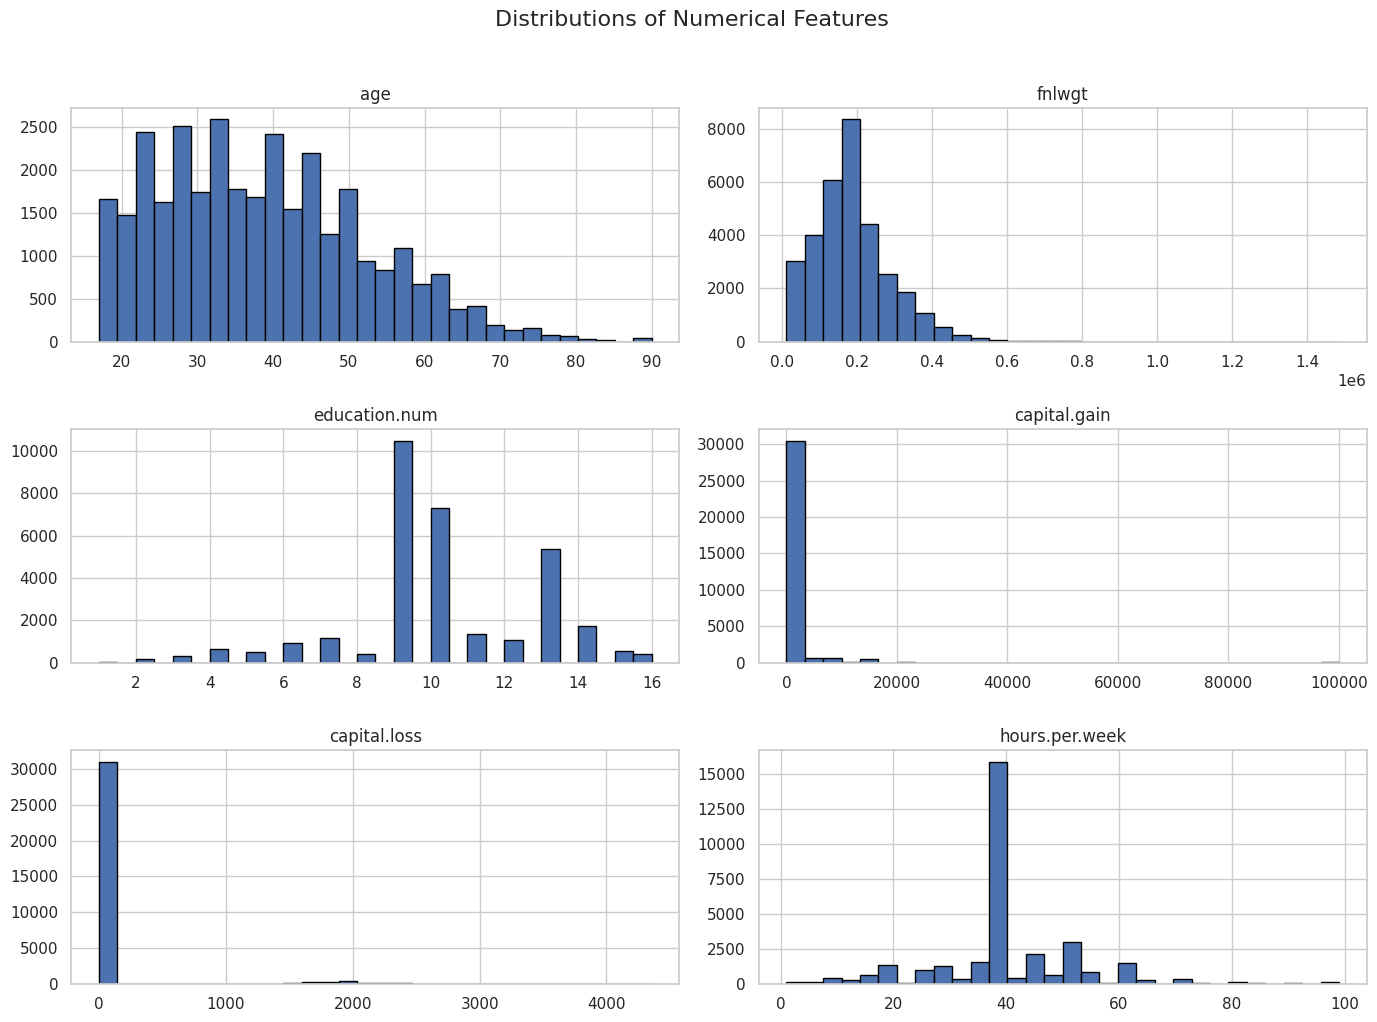

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns


sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
numeric_columns = adult_income.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_columns = adult_income.select_dtypes(include=["object"]).columns.tolist()
adult_income[numeric_columns].hist(
    bins=30,
    figsize=(14, 10),
    edgecolor="black"
)

plt.suptitle("Distributions of Numerical Features", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

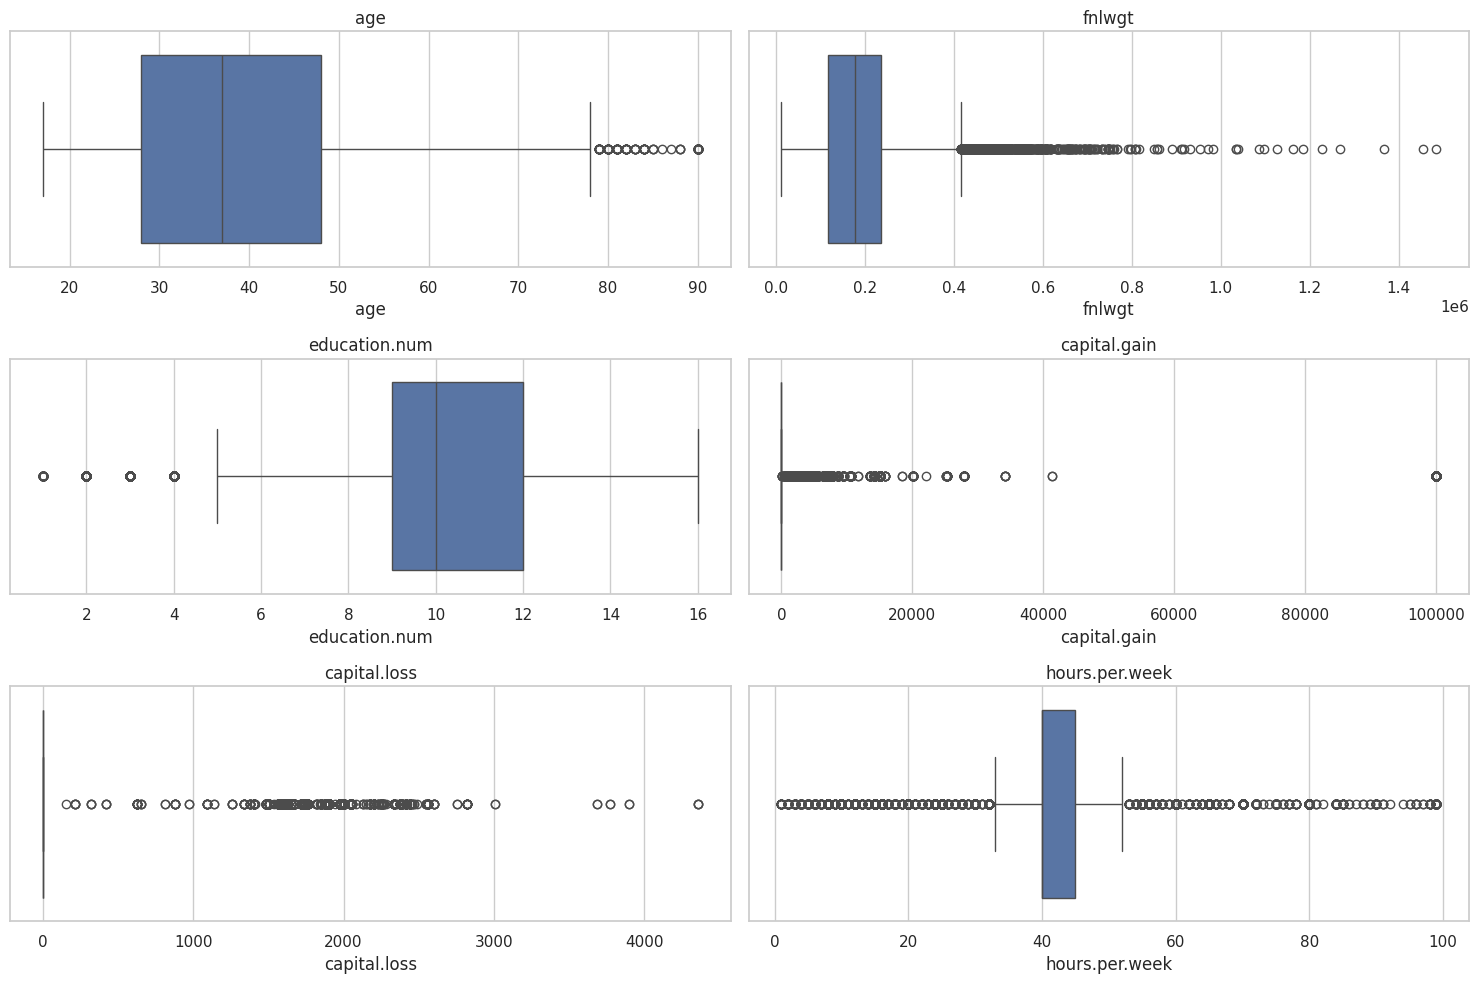

In [25]:
fig, axes = plt.subplots(3, 2, figsize=(15, 10))

axes = axes.flatten()

for ax, column in zip(axes, numeric_columns):
    sns.boxplot(data=adult_income, x=column, ax=ax)
    ax.set_title(column)

plt.tight_layout()
plt.show()

**Numerical distribution notes**

The numerical variables show different distribution patterns. `age` is moderately right-skewed, while `hours.per.week` is concentrated around standard full-time working hours.

The variables `capital.gain` and `capital.loss` are highly right-skewed, with most values equal to zero and a small number of large values. This suggests that additional binary features, such as whether a person has capital gain or capital loss, may be useful during feature engineering.

The boxplots show potential extreme values in several numerical variables. However, these values may represent valid real-world observations rather than data entry errors. Therefore, outlier treatment decisions will be made carefully during the preprocessing section.

In [ ]:
categorical_cardinality = pd.DataFrame({
    "unique_values": adult_income[categorical_columns].nunique(),
    "most_frequent_value": adult_income[categorical_columns].mode().iloc[0],
    "most_frequent_count": [
        adult_income[column].value_counts().iloc[0] for column in categorical_columns
    ]
}).sort_values(by="unique_values", ascending=False)

display(categorical_cardinality)

,unique_values,most_frequent_value,most_frequent_count
native.country,42,United-States,29170
education,16,HS-grad,10501
occupation,15,Prof-specialty,4140
workclass,9,Private,22696
marital.status,7,Married-civ-spouse,14976
relationship,6,Husband,13193
race,5,White,27816
sex,2,Male,21790
income,2,<=50K,24720


In [ ]:
for column in categorical_columns:
    print(f"\n{column}")
    display(adult_income[column].value_counts().head(10).to_frame(name="count"))


workclass


,count
workclass,
Private,22696
Self-emp-not-inc,2541
Local-gov,2093
?,1836
State-gov,1298
Self-emp-inc,1116
Federal-gov,960
Without-pay,14
Never-worked,7



education


,count
education,
HS-grad,10501
Some-college,7291
Bachelors,5355
Masters,1723
Assoc-voc,1382
11th,1175
Assoc-acdm,1067
10th,933
7th-8th,646



marital.status


...

,count
sex,
Male,21790
Female,10771



native.country


,count
native.country,
United-States,29170
Mexico,643
?,583
Philippines,198
Germany,137
Canada,121
Puerto-Rico,114
El-Salvador,106
India,100



income


,count
income,
<=50K,24720
>50K,7841


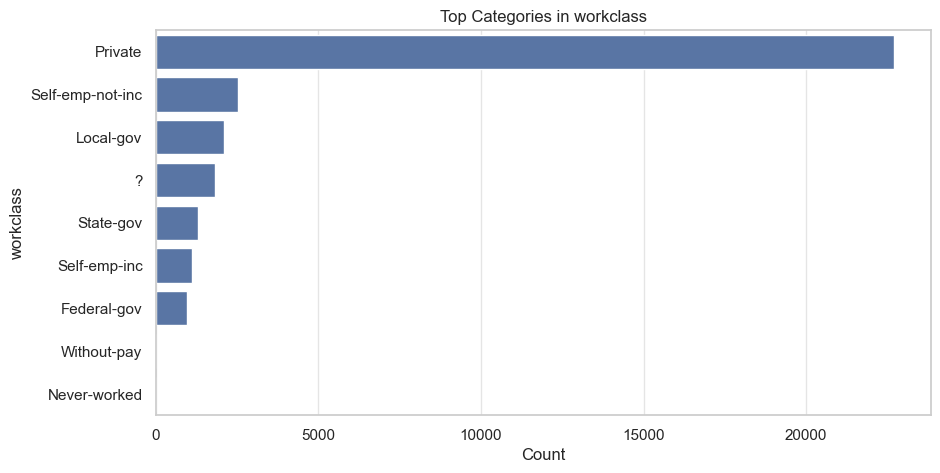

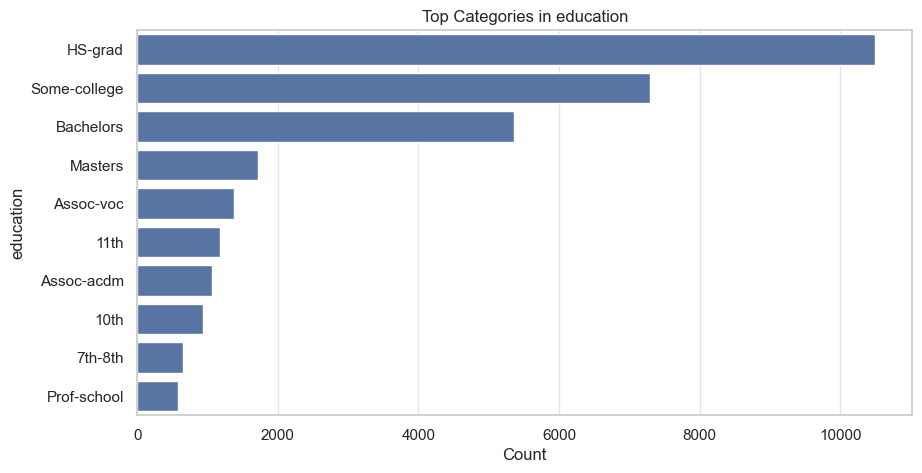

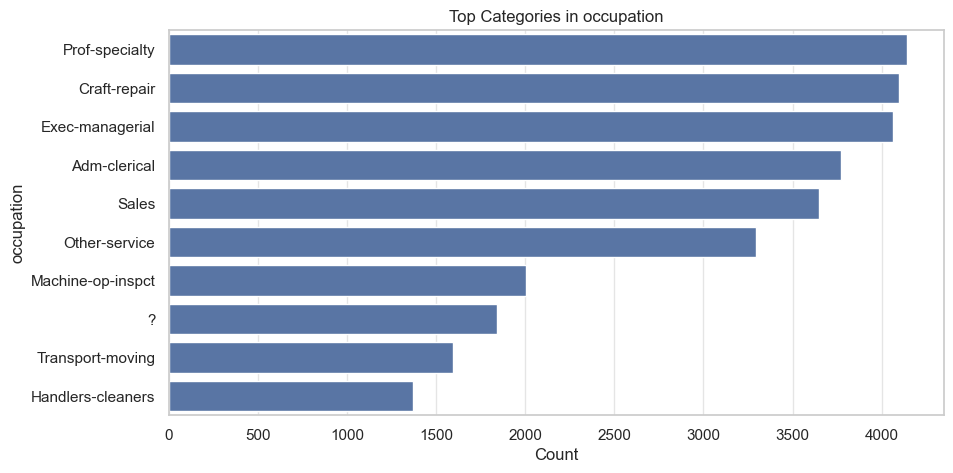

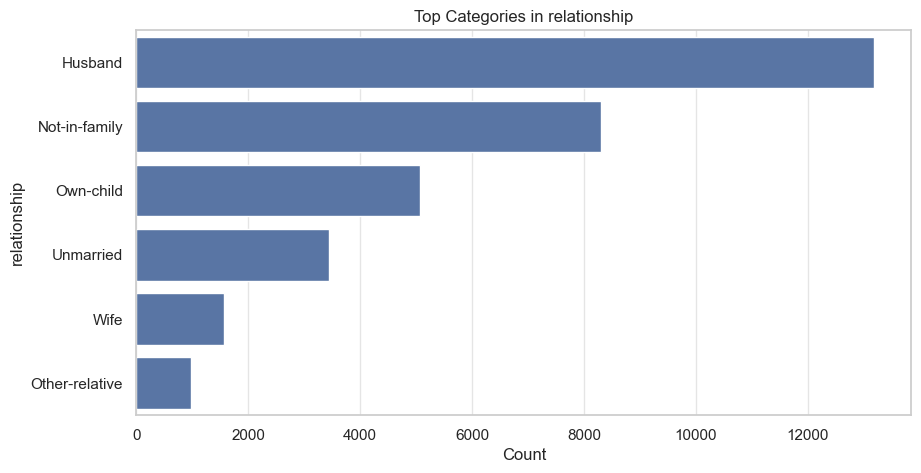

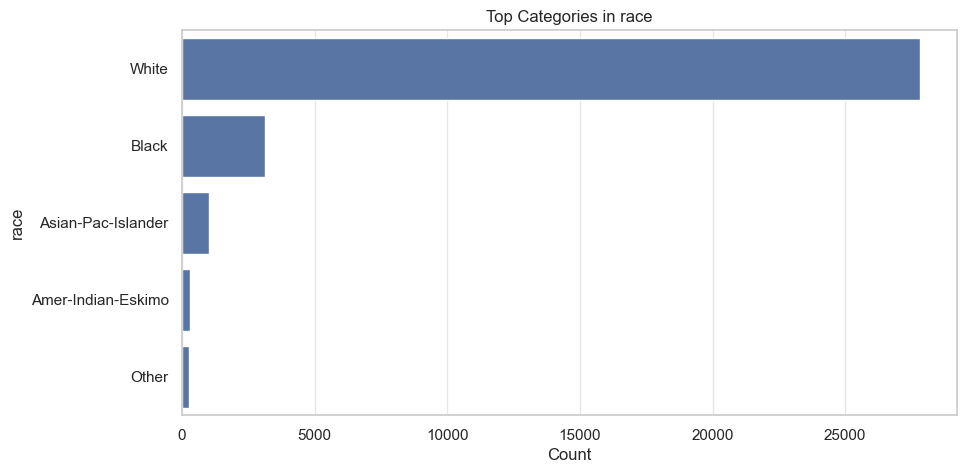

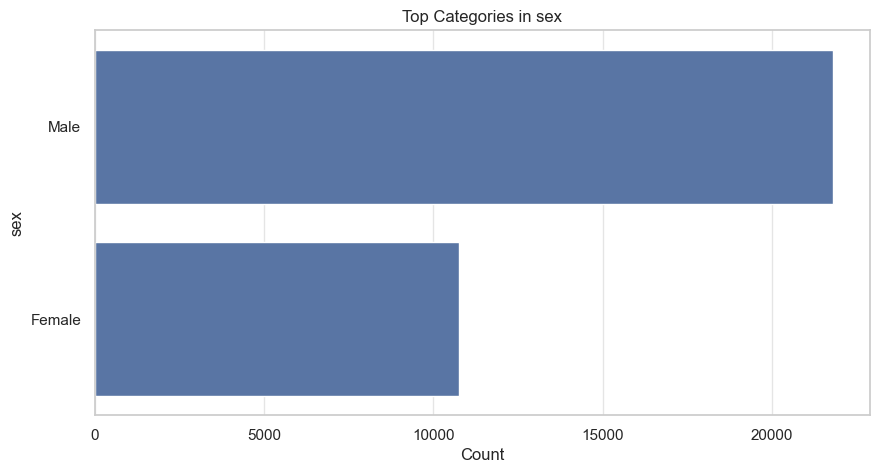

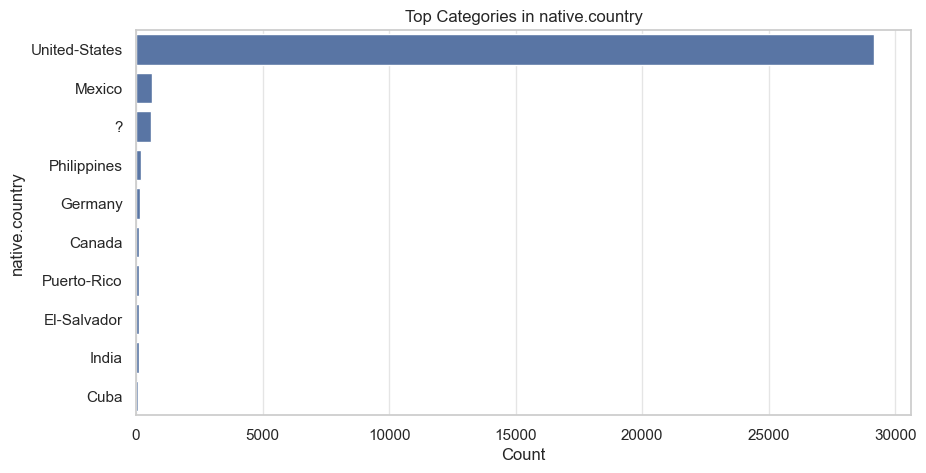

In [ ]:
key_categorical_columns = [
    "workclass",
    "education",
    "occupation",
    "relationship",
    "race",
    "sex",
    "native.country"
]

for column in key_categorical_columns:
    plt.figure(figsize=(10, 5))

    order = adult_income[column].value_counts().head(10).index

    sns.countplot(
        data=adult_income,
        y=column,
        order=order
    )

    plt.title(f"Top Categories in {column}")
    plt.xlabel("Count")
    plt.ylabel(column)
    plt.show()

In [ ]:
missing_marker_counts = (adult_income[categorical_columns] == "?").sum()
missing_marker_counts = missing_marker_counts[missing_marker_counts > 0].sort_values(ascending=False)

display(missing_marker_counts.to_frame(name="question_mark_count"))

,question_mark_count
occupation,1843
workclass,1836
native.country,583


**Categorical distribution notes**

The categorical variables show different levels of cardinality. Variables such as `native.country`, `occupation`, and `education` contain many distinct categories, while `sex` and `income` contain only two categories.

Several variables are dominated by a small number of frequent categories. For example, `United-States` is expected to be the most common value in `native.country`, which may limit the representativeness of smaller country groups.

The `?` symbol appears in some categorical variables, indicating that missing information is encoded as a string rather than as a standard null value. This will be handled during the preprocessing section.

In [ ]:
def plot_income_rate_by_category(data: pd.DataFrame, column: str, top_n: None) -> None:
    """Plot the percentage of people earning >50K for each category in a column."""
    plot_data = data.copy()

    if top_n is not None:
        top_categories = plot_data[column].value_counts().head(top_n).index
        plot_data = plot_data[plot_data[column].isin(top_categories)]

    income_rate = (
        plot_data
        .groupby(column)["income"]
        .apply(lambda values: (values == ">50K").mean() * 100)
        .sort_values(ascending=False)
    )

    plt.figure(figsize=(10, 5))
    sns.barplot(x=income_rate.values, y=income_rate.index)

    plt.title(f"Percentage of >50K Income by {column}")
    plt.xlabel("Percentage earning >50K")
    plt.ylabel(column)
    plt.show()

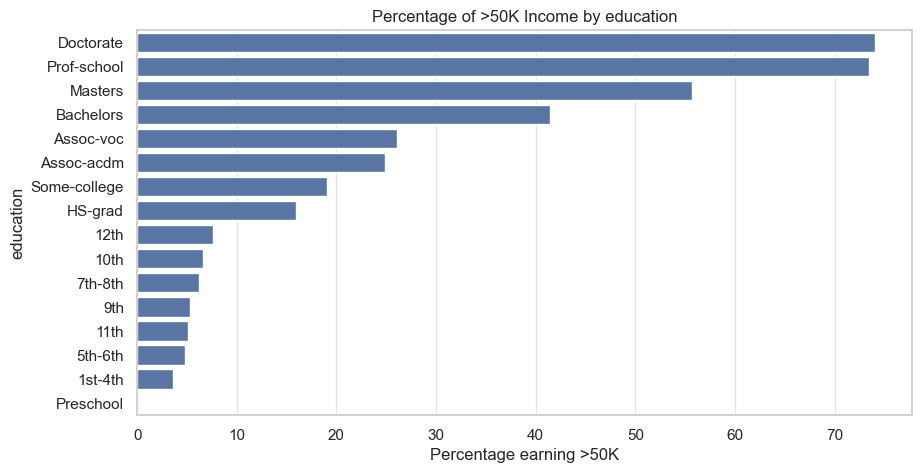

In [ ]:
plot_income_rate_by_category(adult_income, "education", None)

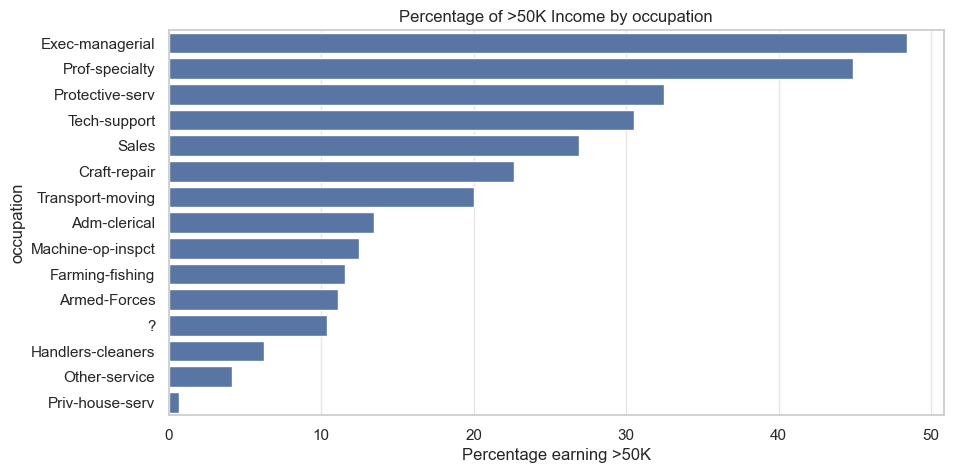

In [ ]:
plot_income_rate_by_category(adult_income, "occupation",None)

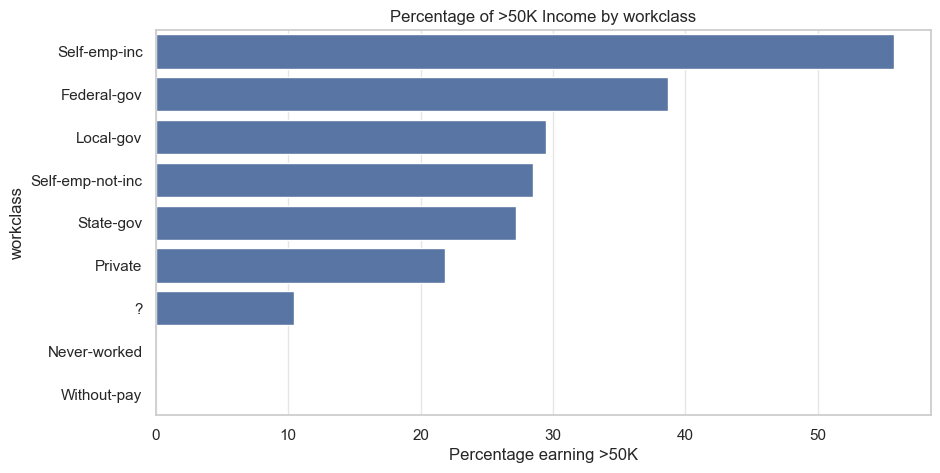

In [ ]:
plot_income_rate_by_category(adult_income, "workclass", None)

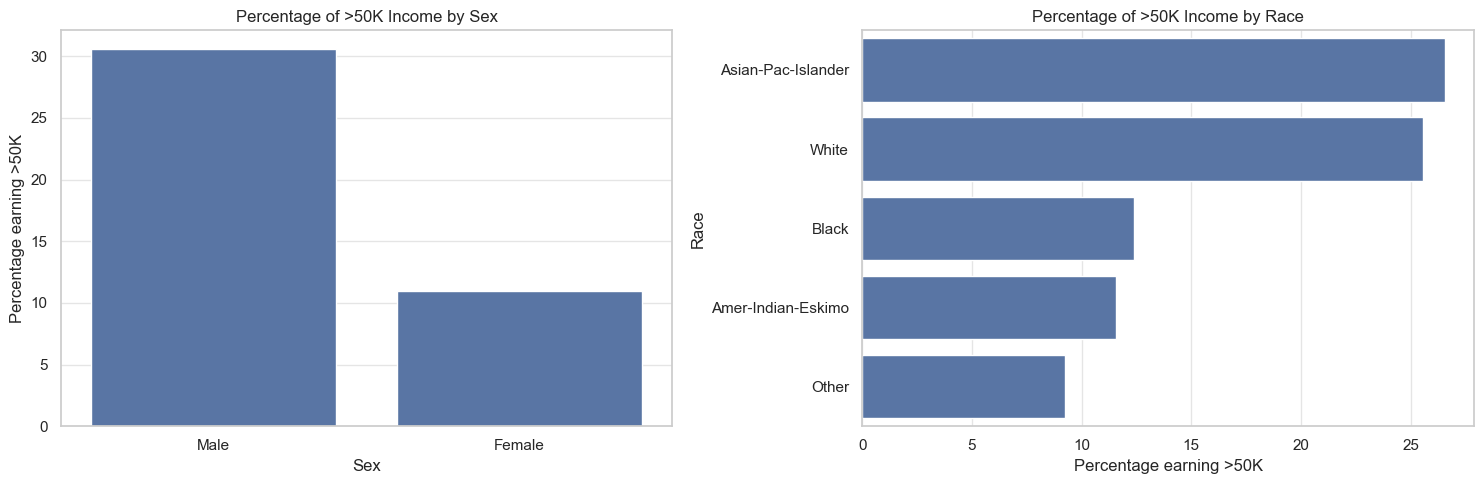

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sex_income_rate = (
    adult_income.groupby("sex")["income"]
    .apply(lambda values: (values == ">50K").mean() * 100)
    .sort_values(ascending=False)
)

race_income_rate = (
    adult_income.groupby("race")["income"]
    .apply(lambda values: (values == ">50K").mean() * 100)
    .sort_values(ascending=False)
)

sns.barplot(x=sex_income_rate.index, y=sex_income_rate.values, ax=axes[0])
axes[0].set_title("Percentage of >50K Income by Sex")
axes[0].set_xlabel("Sex")
axes[0].set_ylabel("Percentage earning >50K")

sns.barplot(x=race_income_rate.values, y=race_income_rate.index, ax=axes[1])
axes[1].set_title("Percentage of >50K Income by Race")
axes[1].set_xlabel("Percentage earning >50K")
axes[1].set_ylabel("Race")

plt.tight_layout()
plt.show()

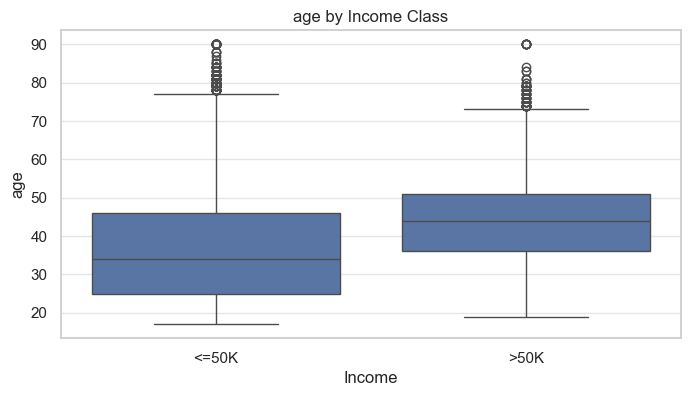

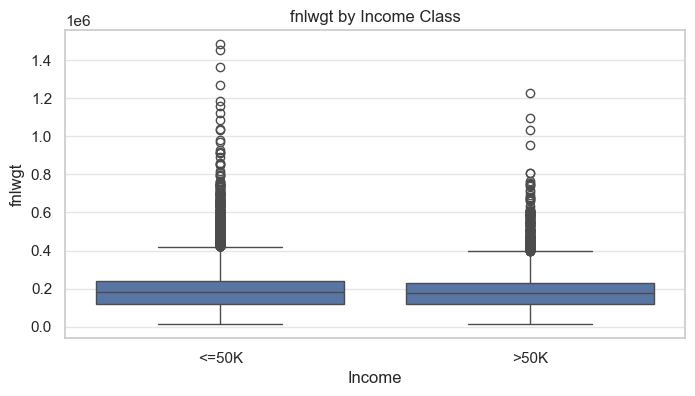

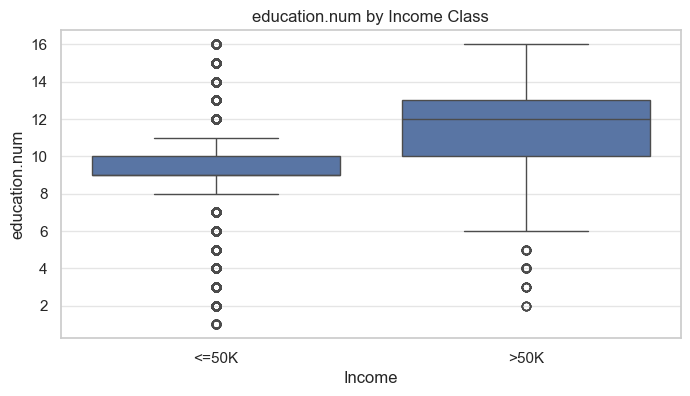

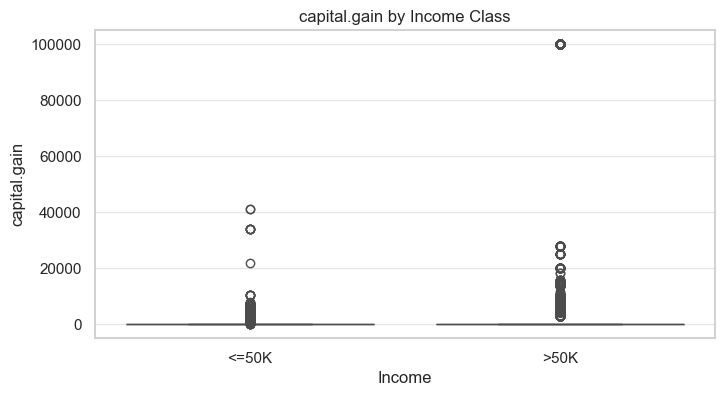

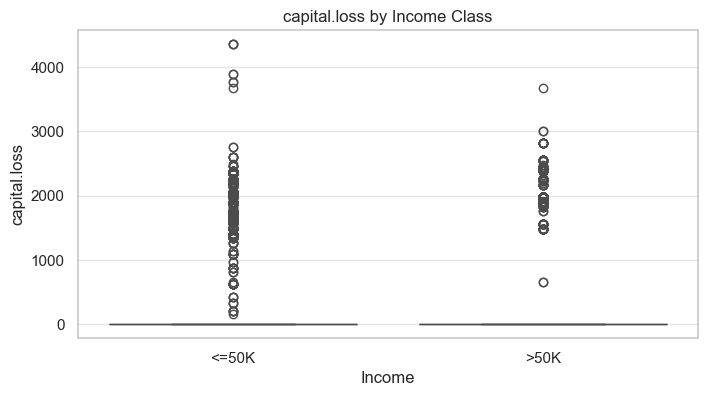

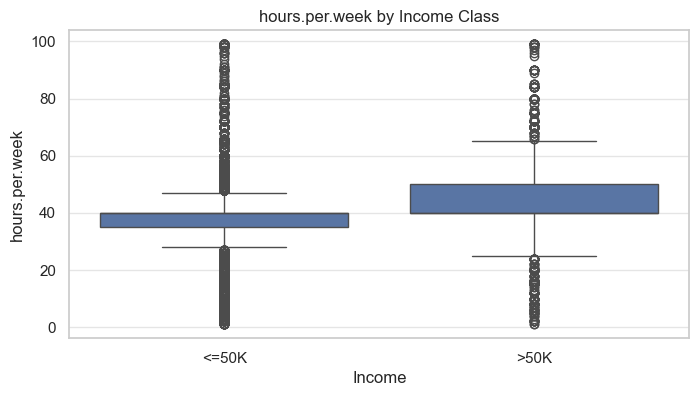

In [ ]:
for column in numeric_columns:
    plt.figure(figsize=(8, 4))

    sns.boxplot(
        data=adult_income,
        x="income",
        y=column
    )

    plt.title(f"{column} by Income Class")
    plt.xlabel("Income")
    plt.ylabel(column)
    plt.show()

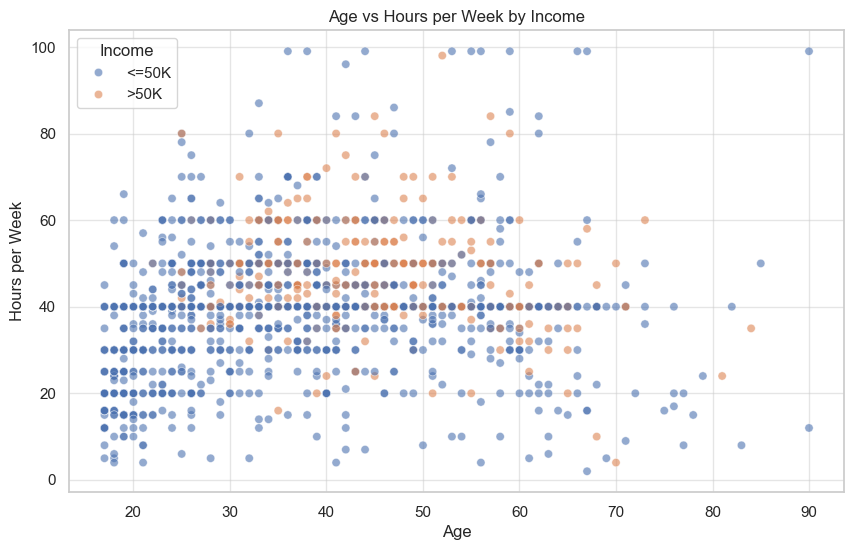

In [ ]:
sample_df = adult_income.sample(2000, random_state=RANDOM_STATE)

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=sample_df,
    x="age",
    y="hours.per.week",
    hue="income",
    alpha=0.6
)

plt.title("Age vs Hours per Week by Income")
plt.xlabel("Age")
plt.ylabel("Hours per Week")
plt.legend(title="Income")
plt.show()

**Relationship analysis notes**

Several features show visible relationships with income. Education level appears strongly related to the probability of earning more than 50K, with higher education categories generally showing higher proportions of high-income records.

Occupation and workclass also show differences in income distribution, suggesting that employment-related variables may be useful predictors.

The analysis by sex and race shows noticeable differences in the observed percentage of high-income records across demographic groups. These differences should be interpreted carefully because they may reflect historical and social inequalities in the data rather than fair or causal relationships.

Numerical variables such as `education.num`, `age`, `capital.gain`, and `hours.per.week` also show differences between income classes. However, some variables are highly skewed, so their relationship with income should be considered carefully during preprocessing and model interpretation.

#### 1.3.6 Correlation Analysis

This subsection examines correlations between numerical variables. Correlation analysis helps identify linear relationships among numerical features and possible redundancy between variables.

Since many important variables in this dataset are categorical, correlation analysis provides only a partial view of feature relationships.

In [ ]:
correlation_matrix = adult_income[numeric_columns].corr()

display(correlation_matrix)

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week
age,1.000000,-0.076646,0.036527,0.077674,0.057775,0.068756
fnlwgt,-0.076646,1.000000,-0.043195,0.000432,-0.010252,-0.018768
education.num,0.036527,-0.043195,1.000000,0.122630,0.079923,0.148123
capital.gain,0.077674,0.000432,0.122630,1.000000,-0.031615,0.078409
capital.loss,0.057775,-0.010252,0.079923,-0.031615,1.000000,0.054256
hours.per.week,0.068756,-0.018768,0.148123,0.078409,0.054256,1.000000


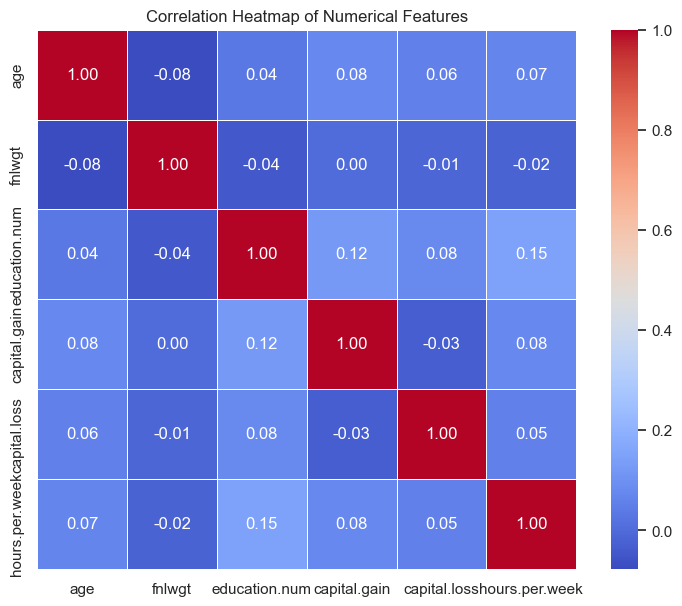

In [ ]:
plt.figure(figsize=(9, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5,
    square=True
)

plt.title("Correlation Heatmap of Numerical Features")
plt.show()

In [ ]:
df_correlation = adult_income.copy()
df_correlation["income_encoded"] = (df_correlation["income"] == ">50K").astype(int)

target_correlations = (
    df_correlation[numeric_columns + ["income_encoded"]]
    .corr()["income_encoded"]
    .drop("income_encoded")
    .sort_values(ascending=False)
)

display(target_correlations.to_frame(name="correlation_with_income"))

,correlation_with_income
education.num,0.335154
age,0.234037
hours.per.week,0.229689
capital.gain,0.223329
capital.loss,0.150526
fnlwgt,-0.009463


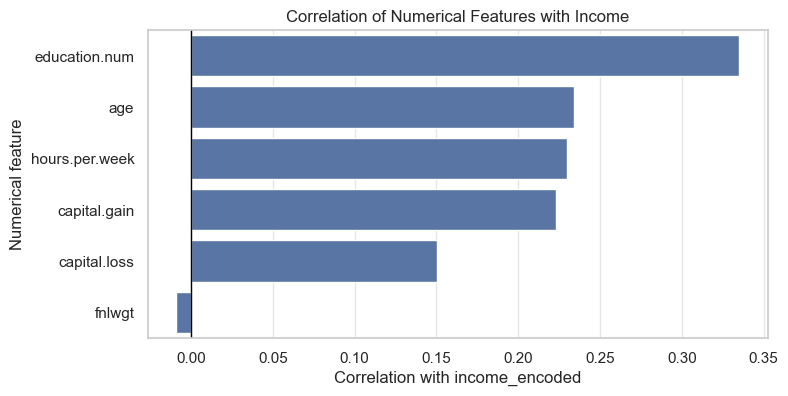

In [ ]:
plt.figure(figsize=(8, 4))

sns.barplot(
    x=target_correlations.values,
    y=target_correlations.index
)

plt.axvline(0, color="black", linewidth=1)
plt.title("Correlation of Numerical Features with Income")
plt.xlabel("Correlation with income_encoded")
plt.ylabel("Numerical feature")
plt.show()

**Correlation analysis notes**

The correlation heatmap shows that most numerical variables have weak to moderate linear relationships with each other. This suggests that there is limited redundancy among the numerical features.

When the income target is temporarily encoded as a binary variable, `education.num`, `capital.gain`, `age`, and `hours.per.week` show positive correlations with earning more than 50K. However, the correlations are not strong enough to fully explain the target variable.

This analysis is limited because several important predictors, such as education, occupation, workclass, sex, and race, are categorical and are not fully represented in the numerical correlation matrix. More complete relationships will be captured later through preprocessing and machine learning models.

#### 1.3.7 Biases and Dataset Limitations

This subsection discusses possible biases and limitations in the Adult Census Income dataset. Since the dataset contains demographic and socioeconomic variables, it is important to consider whether the data may reflect historical inequalities or sampling limitations.

The goal at this stage is not to remove variables or make fairness conclusions, but to identify issues that should be considered during model evaluation and interpretation.

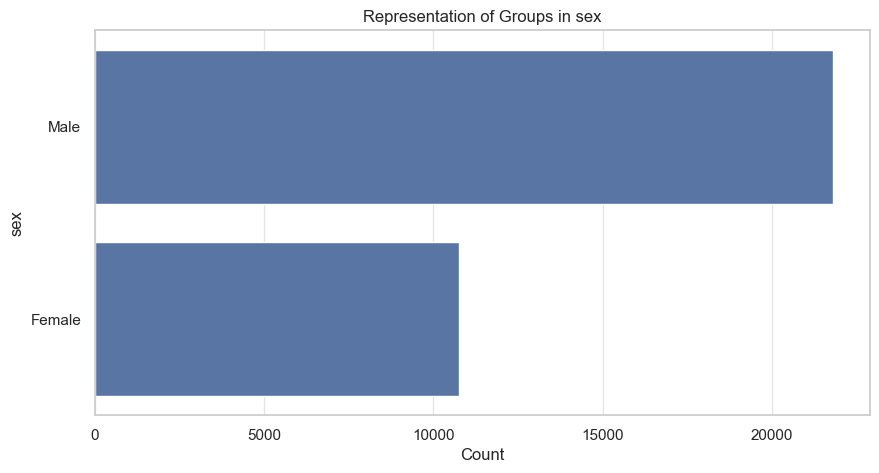

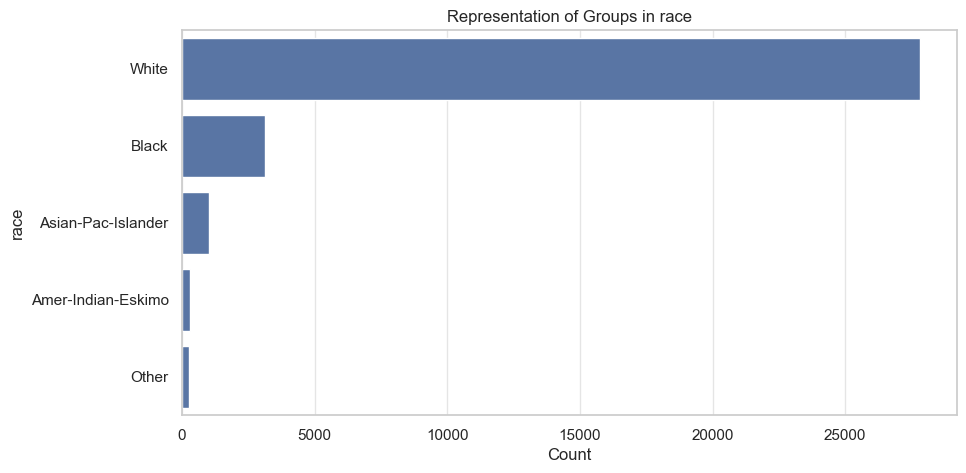

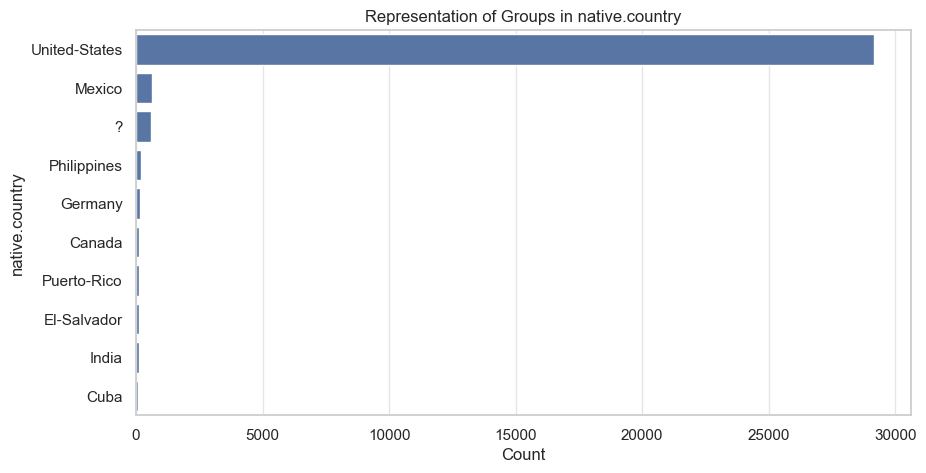

In [ ]:
sensitive_columns = ["sex", "race", "native.country"]

for column in sensitive_columns:
    plt.figure(figsize=(10, 5))

    order = adult_income[column].value_counts().head(10).index

    sns.countplot(
        data=adult_income,
        y=column,
        order=order
    )

    plt.title(f"Representation of Groups in {column}")
    plt.xlabel("Count")
    plt.ylabel(column)
    plt.show()

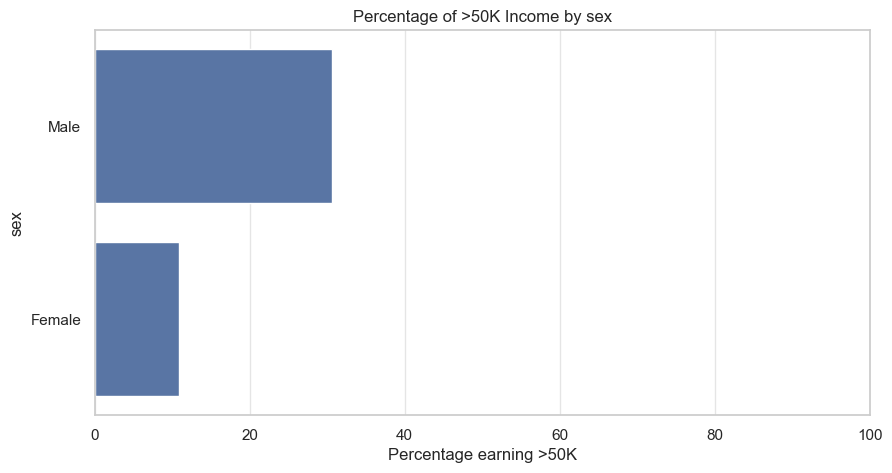

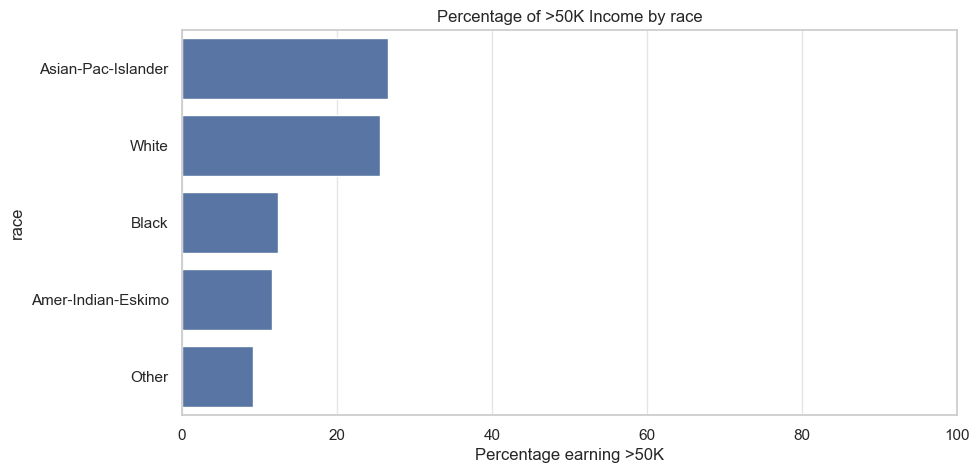

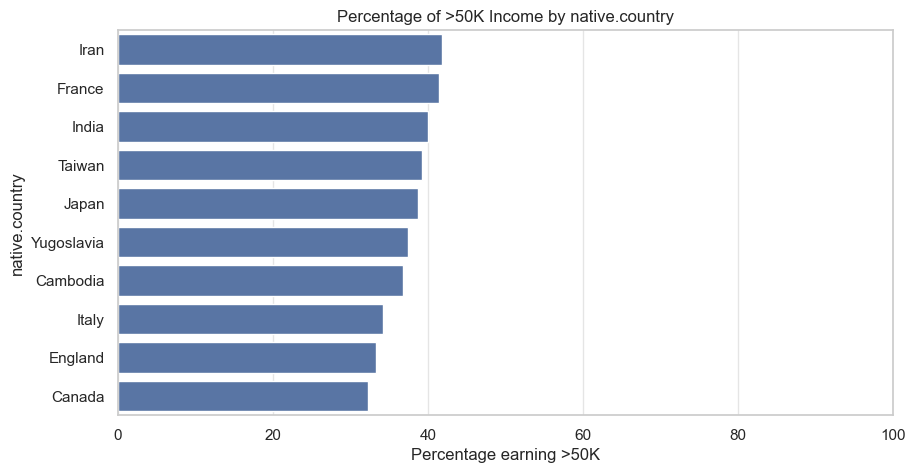

In [ ]:
for column in sensitive_columns:
    income_rate = (
        adult_income.groupby(column)["income"]
        .apply(lambda values: (values == ">50K").mean() * 100)
        .sort_values(ascending=False)
        .head(10)
    )

    plt.figure(figsize=(10, 5))

    sns.barplot(
        x=income_rate.values,
        y=income_rate.index
    )

    plt.title(f"Percentage of >50K Income by {column}")
    plt.xlabel("Percentage earning >50K")
    plt.ylabel(column)
    plt.xlim(0, 100)
    plt.show()

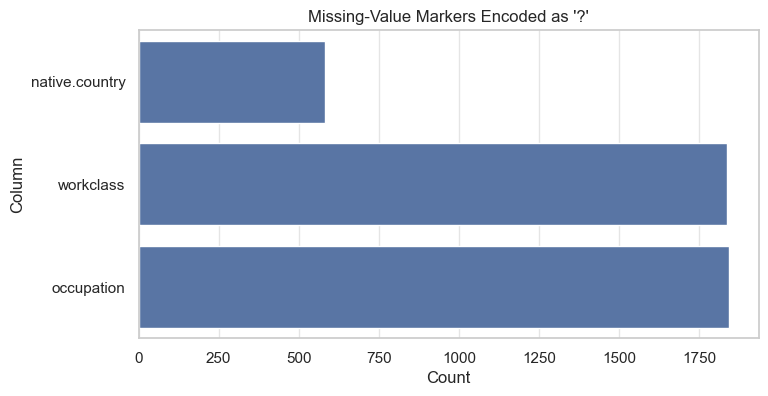

In [ ]:
missing_marker_counts = (adult_income == "?").sum()
missing_marker_counts = missing_marker_counts[missing_marker_counts > 0].sort_values(ascending=True)

plt.figure(figsize=(8, 4))

sns.barplot(
    x=missing_marker_counts.values,
    y=missing_marker_counts.index
)

plt.title("Missing-Value Markers Encoded as '?'")
plt.xlabel("Count")
plt.ylabel("Column")
plt.show()

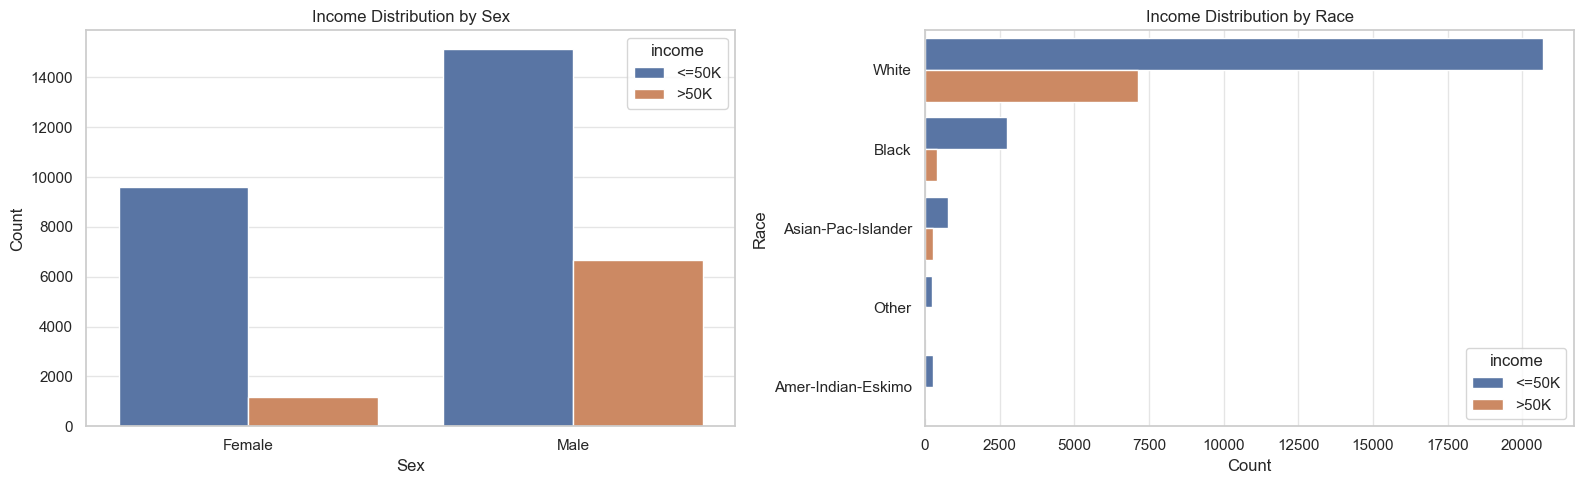

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.countplot(
    data=adult_income,
    x="sex",
    hue="income",
    ax=axes[0]
)

axes[0].set_title("Income Distribution by Sex")
axes[0].set_xlabel("Sex")
axes[0].set_ylabel("Count")

sns.countplot(
    data=adult_income,
    y="race",
    hue="income",
    ax=axes[1]
)

axes[1].set_title("Income Distribution by Race")
axes[1].set_xlabel("Count")
axes[1].set_ylabel("Race")

plt.tight_layout()
plt.show()

**Biases and dataset limitations notes**

The visualizations show that some demographic groups are much more represented than others. For example, `native.country` is strongly dominated by a small number of categories, especially the United States. This may limit how well patterns generalize to underrepresented country groups.

The income-rate plots show visible differences in the proportion of `>50K` income across demographic groups such as sex and race. These differences should not be interpreted as causal effects. Instead, they suggest that the dataset may reflect historical and socioeconomic inequalities.

The dataset also contains missing-value markers encoded as `?`, especially in categorical variables. These values are not treated as missing values by default in pandas and must be handled explicitly during preprocessing.

These limitations do not make the dataset unusable, but they require careful preprocessing, evaluation, and interpretation to avoid drawing misleading conclusions.

## 2. Data Preprocessing and Feature Engineering

This section prepares the dataset for machine learning. It includes missing data handling, duplicate record analysis, outlier detection, feature engineering, and the construction of preprocessing steps required for model training.

### 2.1 Missing Data Analysis

The initial inspection showed that some missing values may be encoded using the `?` symbol rather than standard null values. This subsection identifies where these markers occur and prepares the dataset for proper missing-value treatment.

In [ ]:
adult_income_df_clean = adult_income.copy()

adult_income_df_clean = adult_income_df_clean.replace("?", np.nan)

print("Missing-value markers converted to NaN.")


Missing-value markers converted to NaN.


In [ ]:
missing_summary = pd.DataFrame({
    "missing_count": adult_income_df_clean.isna().sum(),
    "missing_percentage": adult_income_df_clean.isna().mean().mul(100).round(2)
})
missing_summary = missing_summary[missing_summary["missing_count"] > 0]
display(missing_summary)

,missing_count,missing_percentage
workclass,1836,5.64
occupation,1843,5.66
native.country,583,1.79


**Missing data analysis notes**

After converting the `?` marker to standard missing values, missing data is observed in a small number of categorical variables. These missing values must be handled before model training.

Because the affected variables are categorical, reasonable treatment options include deleting rows with missing values or imputing missing categories using a strategy such as the most frequent category or an explicit `Unknown` category.

### 2.2 Missing Data Treatment

Missing values occur in categorical variables and were originally encoded using the `?` symbol. Instead of deleting rows, these missing values are replaced with the category `Unknown`.

This strategy preserves the dataset size and makes missing information explicit. It is appropriate here because the missing values occur in categorical fields where an unknown category can be represented directly.

In [ ]:
adult_income_df_clean = adult_income_df_clean.fillna("Unknown")

print("Missing categorical values replaced with 'Unknown'.")
print(f"Remaining missing values: {adult_income_df_clean.isna().sum().sum()}")

Missing categorical values replaced with 'Unknown'.
Remaining missing values: 0


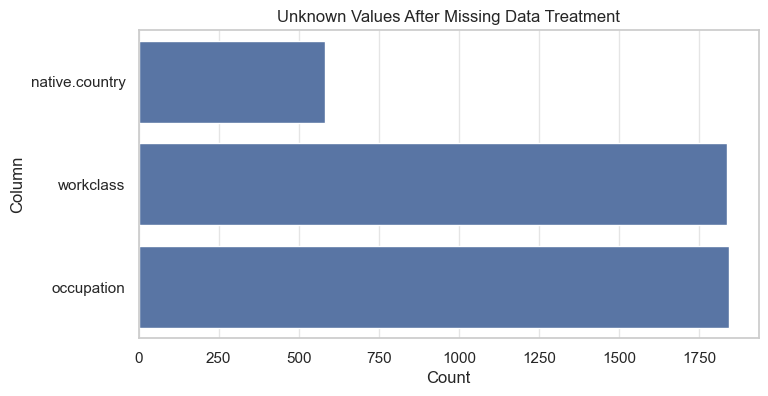

In [ ]:
unknown_counts = (adult_income_df_clean == "Unknown").sum()
unknown_counts = unknown_counts[unknown_counts > 0].sort_values(ascending=True)

plt.figure(figsize=(8, 4))

sns.barplot(
    x=unknown_counts.values,
    y=unknown_counts.index
)

plt.title("Unknown Values After Missing Data Treatment")
plt.xlabel("Count")
plt.ylabel("Column")
plt.show()

In [ ]:
# ============================================
# Reset Dataset Index
# ============================================

adult_income.reset_index(drop=True, inplace=True)

print("Dataset index reset successfully.")

Dataset index reset successfully.


**Missing data treatment notes**

Missing categorical values were replaced with the explicit category `Unknown`. This avoids reducing the dataset size and allows the models to treat missing or unreported information as a separate category.

This approach is preferable to row deletion in this project because deleting records could remove useful information and potentially affect group representation in the dataset.

### 2.3 Duplicate Records

Duplicate records can introduce redundancy and may bias model training if the same observation appears multiple times. This subsection checks for exact duplicate rows and removes them if present.

In [ ]:
duplicate_count = adult_income_df_clean.duplicated().sum()

print(f"Number of duplicate records: {duplicate_count:,}")
print(f"Percentage of duplicate records: {duplicate_count / len(adult_income_df_clean) * 100:.2f}%")

Number of duplicate records: 24
Percentage of duplicate records: 0.07%


In [ ]:
rows_before = len(adult_income_df_clean)

adult_income_df_clean = adult_income_df_clean.drop_duplicates().reset_index(drop=True)

rows_after = len(adult_income_df_clean)

print(f"Rows before duplicate removal: {rows_before:,}")
print(f"Rows after duplicate removal: {rows_after:,}")
print(f"Rows removed: {rows_before - rows_after:,}")

Rows before duplicate removal: 32,561
Rows after duplicate removal: 32,537
Rows removed: 24


**Duplicate records notes**

Exact duplicate records were removed to reduce redundancy in the dataset. Removing duplicates helps ensure that repeated observations do not have unnecessary influence during model training and evaluation.

## 2.4 Outlier Detection

This subsection identifies potential outliers in numerical variables using boxplots and the interquartile range (IQR) method. Outliers are not removed automatically because extreme values may represent valid real-world cases, especially for variables such as capital gain, capital loss, and working hours.

In [ ]:
numeric_columns_clean = adult_income_df_clean.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Numerical columns:")
for column in numeric_columns_clean:
    print(f"- {column}")

Numerical columns:
- age
- fnlwgt
- education.num
- capital.gain
- capital.loss
- hours.per.week


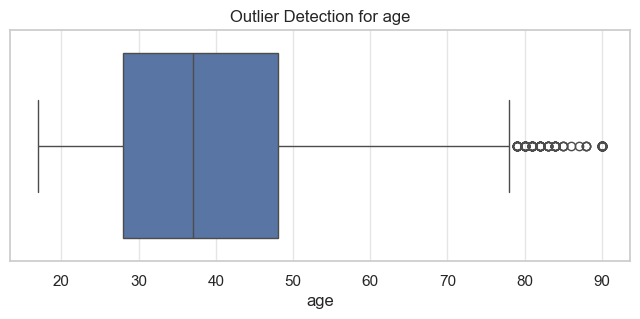

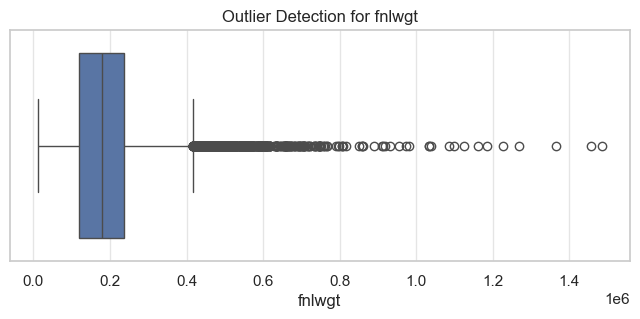

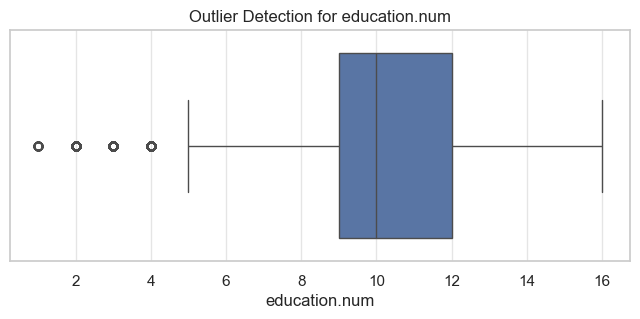

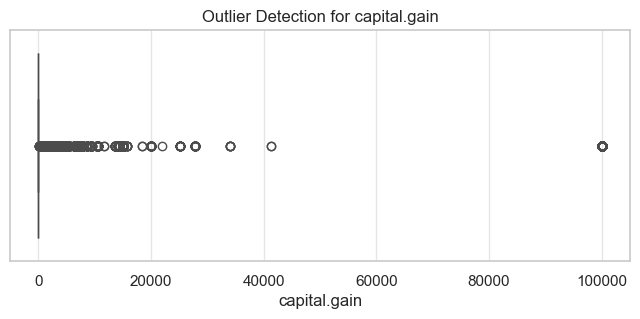

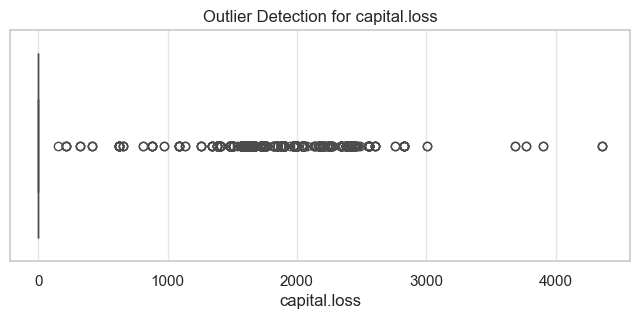

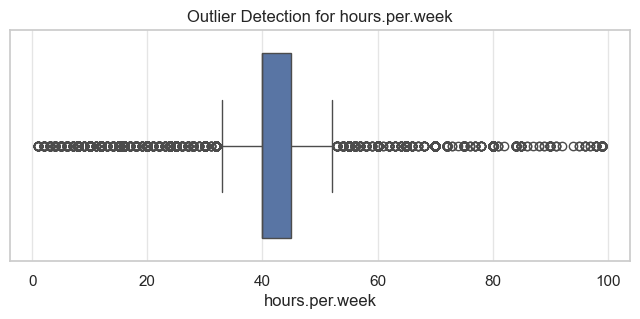

In [ ]:
for column in numeric_columns_clean:
    plt.figure(figsize=(8, 3))

    sns.boxplot(
        data=adult_income_df_clean,
        x=column
    )

    plt.title(f"Outlier Detection for {column}")
    plt.xlabel(column)
    plt.show()

**Outlier detection notes**

The boxplots indicate potential outliers in several numerical variables. `capital.gain` and `capital.loss` show many extreme values because most records have zero values while a small number of individuals report high capital gains or losses.

Some outliers are also visible in variables such as `hours.per.week`, `age`, and `fnlwgt`. However, these values may represent valid real-world observations rather than data entry errors.

For this reason, outliers will not be removed automatically. The treatment decision will be made based on the meaning of each variable and the needs of the modeling pipeline.

### 2.6 Feature Engineering

Feature engineering is used to create additional meaningful variables from existing features. The goal is to improve interpretability and help models capture important patterns in the data.

The engineered features include:

- `has.capital.gain`: whether the individual has any capital gain;
- `has.capital.loss`: whether the individual has any capital loss;
- `education.level`: grouped education level;
- `is.married`: simplified marital status indicator;
- `work.intensity`: interaction between weekly working hours and education number;
- `age.group`: broad age category;
- `native.country.region`: grouped native country region.

In [ ]:
def group_education(education: str) -> str:
    """Group detailed education categories into broader education levels."""
    if education in ["Bachelors", "Masters", "Doctorate", "Prof-school"]:
        return "Higher"

    if education in ["HS-grad", "Some-college", "Assoc-acdm", "Assoc-voc"]:
        return "Medium"

    return "Low"


def group_native_country(country: str) -> str:
    """Group native country into broader geographic regions."""
    north_america = [
        "United-States", "Canada", "Outlying-US(Guam-USVI-etc)"
    ]

    latin_america_caribbean = [
        "Mexico", "Cuba", "Jamaica", "El-Salvador", "Dominican-Republic",
        "Guatemala", "Columbia", "Haiti", "Nicaragua", "Peru", "Ecuador",
        "Trinadad&Tobago", "Honduras", "Puerto-Rico"
    ]

    europe = [
        "England", "Germany", "France", "Italy", "Poland", "Portugal",
        "Greece", "Ireland", "Hungary", "Scotland", "Holand-Netherlands",
        "Yugoslavia"
    ]

    asia = [
        "Philippines", "India", "China", "Japan", "Vietnam", "Taiwan",
        "Hong", "Cambodia", "Laos", "Thailand", "South", "Iran"
    ]

    if country in north_america:
        return "North-America"

    if country in latin_america_caribbean:
        return "Latin-America-Caribbean"

    if country in europe:
        return "Europe"

    if country in asia:
        return "Asia"

    if country == "Unknown":
        return "Unknown"

    return "Other"

In [ ]:
def engineer_features(data: pd.DataFrame) -> pd.DataFrame:
    """Create interpretable engineered features for income prediction."""
    engineered_data = data.copy()

    engineered_data["has.capital.gain"] = (
        engineered_data["capital.gain"] > 0
    ).astype(int)

    engineered_data["has.capital.loss"] = (
        engineered_data["capital.loss"] > 0
    ).astype(int)

    engineered_data["education.level"] = (
        engineered_data["education"].apply(group_education)
    )

    engineered_data["is.married"] = (
        engineered_data["marital.status"].str.contains("Married", regex=False)
    ).astype(int)

    engineered_data["work.intensity"] = (
        engineered_data["hours.per.week"] * engineered_data["education.num"]
    )

    engineered_data["age.group"] = pd.cut(
        engineered_data["age"],
        bins=[0, 25, 45, 65, 100],
        labels=["Young", "Adult", "Middle_Aged", "Senior"],
        include_lowest=True
    )

    engineered_data["native.country.region"] = (
        engineered_data["native.country"].apply(group_native_country)
    )

    return engineered_data

In [ ]:
df_model = engineer_features(adult_income_clean)
print("Feature engineering completed.")
print(f"Dataset shape after feature engineering: {df_model.shape}")

Feature engineering completed.
Dataset shape after feature engineering: (32561, 22)


In [ ]:
engineered_columns = [
    "has.capital.gain",
    "has.capital.loss",
    "education.level",
    "is.married",
    "work.intensity",
    "age.group",
    "native.country.region"
]

display(df_model[engineered_columns].head())

,has.capital.gain,has.capital.loss,education.level,is.married,work.intensity,age.group,native.country.region
0,0,1,Medium,0,360,Senior,North-America
1,0,1,Medium,0,162,Senior,North-America
2,0,1,Medium,0,400,Senior,North-America
3,0,1,Low,0,160,Middle_Aged,North-America
4,0,1,Medium,0,400,Adult,North-America


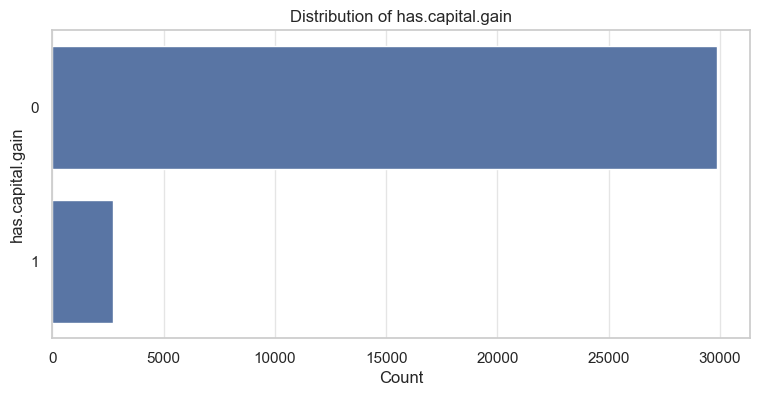

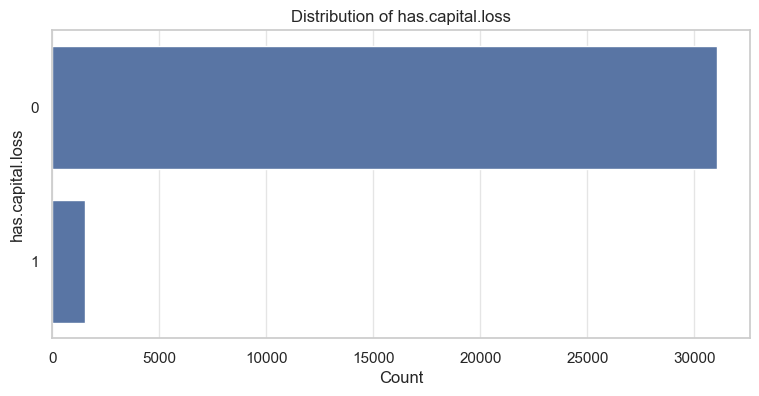

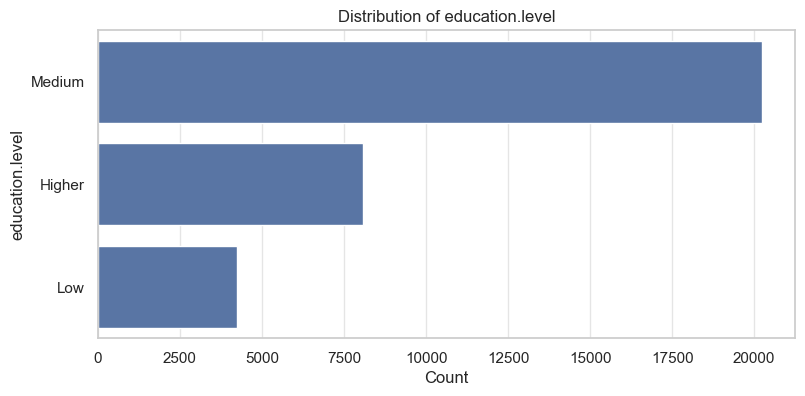

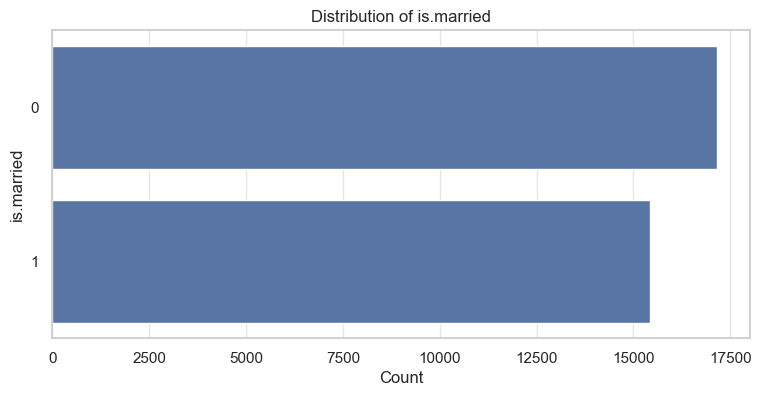

<Figure size 900x400 with 0 Axes>

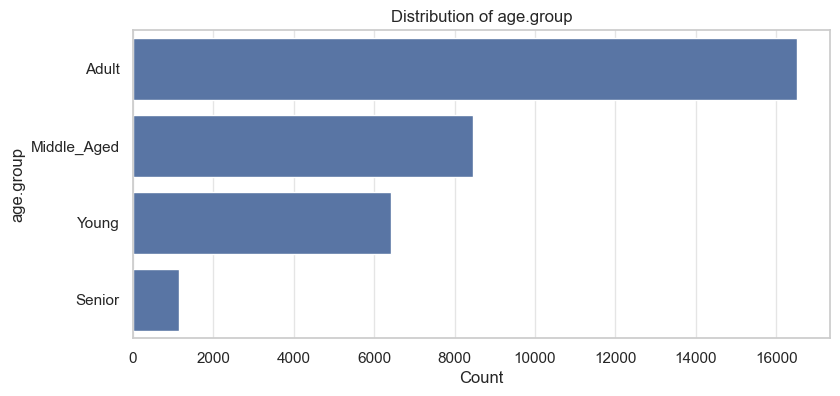

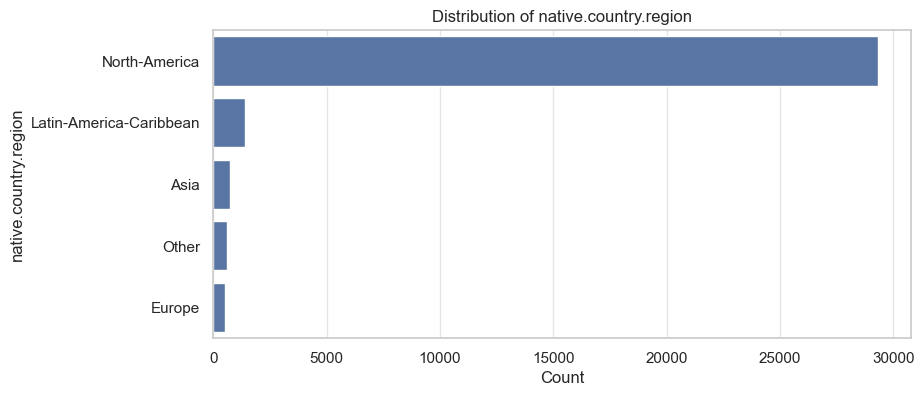

In [ ]:
for column in engineered_columns:
    plt.figure(figsize=(9, 4))

    if df_model[column].nunique() <= 10:
        sns.countplot(
            data=df_model,
            y=column,
            order=df_model[column].value_counts().index
        )

        plt.title(f"Distribution of {column}")
        plt.xlabel("Count")
        plt.ylabel(column)
        plt.show()

**Feature engineering notes**

The capital gain and loss indicators simplify sparse and highly skewed financial variables into interpretable binary signals. These indicators are useful because most records have zero capital gain or loss.

Education was grouped into broader levels to reduce fragmentation and improve interpretability. Marital status was simplified into a binary married indicator because marital status is strongly associated with income patterns in this dataset.

The `work.intensity` feature captures an interaction between education level and weekly working hours. This may help models represent combined effects of education and labor participation.

Age and native country were grouped to capture broader patterns and reduce categorical complexity. These transformations improve interpretability, but they also reduce detail, so they should be discussed as modeling choices rather than objective truths.

### 2.7 Feature and Target Separation

This subsection separates the dataset into input features and target labels for supervised learning.

The target variable is `income`, which represents the binary classification outcome. The feature matrix contains the remaining variables used for prediction.

The variable `fnlwgt` is excluded from the model features because it is a census sampling weight rather than a direct personal, educational, or employment characteristic. Removing it improves interpretability.

In [ ]:
TARGET_COLUMN = "income"

columns_to_drop = [
    TARGET_COLUMN,
    "fnlwgt"
]

In [ ]:
X = df_model.drop(columns=columns_to_drop)
y = df_model[TARGET_COLUMN]

print(f"Feature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")

Feature matrix shape: (32561, 20)
Target vector shape: (32561,)


In [ ]:
model_numeric_columns = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
model_categorical_columns = X.select_dtypes(include=["object", "category"]).columns.tolist()

print("Numerical model features:")
for column in model_numeric_columns:
    print(f"- {column}")

print("\nCategorical model features:")
for column in model_categorical_columns:
    print(f"- {column}")

Numerical model features:
- age
- education.num
- capital.gain
- capital.loss
- hours.per.week
- has.capital.gain
- has.capital.loss
- is.married
- work.intensity

Categorical model features:
- workclass
- education
- marital.status
- occupation
- relationship
- race
- sex
- native.country
- education.level
- age.group
- native.country.region


In [ ]:
y_encoded = (y == ">50K").astype(int)

print("Target encoding:")
print("<=50K -> 0")
print(">50K  -> 1")

print("\nEncoded target distribution:")
print(y_encoded.value_counts())

Target encoding:
<=50K -> 0
>50K  -> 1

Encoded target distribution:
income
0    24720
1     7841
Name: count, dtype: int64


**Feature and target separation notes**

The dataset was separated into a feature matrix `X` and target vector `y`. The target was encoded as a binary variable where `<=50K` is represented as 0 and `>50K` is represented as 1.

The `fnlwgt` column was removed from the model features because it represents a census weighting factor rather than a directly interpretable individual characteristic. The numerical and categorical feature lists were then recomputed from `X` to avoid accidentally including the target variable in the preprocessing pipeline.

### 2.8 Categorical Encoding and Numerical Scaling

Machine learning algorithms require numerical input. Therefore, categorical variables must be encoded before model training.

This project uses one-hot encoding for categorical features because the categorical variables do not have a natural numerical order. Numerical features are imputed using the median. Scaling is applied for models that are sensitive to feature magnitude, such as Logistic Regression, but is not required for tree-based models.

All preprocessing steps are placed inside scikit-learn pipelines to reduce the risk of data leakage and improve reproducibility.

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
numeric_preprocessor_scaled = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

numeric_preprocessor_unscaled = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])
categorical_preprocessor = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

In [ ]:
preprocessor_scaled = ColumnTransformer(
    transformers=[
        ("num", numeric_preprocessor_scaled, model_numeric_columns),
        ("cat", categorical_preprocessor, model_categorical_columns)
    ]
)

preprocessor_unscaled = ColumnTransformer(
    transformers=[
        ("num", numeric_preprocessor_unscaled, model_numeric_columns),
        ("cat", categorical_preprocessor, model_categorical_columns)
    ]
)

print("Preprocessing pipelines created successfully.")

Preprocessing pipelines created successfully.


In [ ]:
preprocessor_unscaled.fit(X)

encoded_feature_names = preprocessor_unscaled.get_feature_names_out()

print(f"Original number of features: {X.shape[1]}")
print(f"Number of features after preprocessing: {len(encoded_feature_names)}")

Original number of features: 20
Number of features after preprocessing: 120


**Encoding and scaling notes**

Categorical features are encoded using one-hot encoding because their categories do not represent a natural numerical order. This avoids introducing artificial ranking between categories.

Two preprocessing pipelines are created. The scaled pipeline standardizes numerical variables and is suitable for models such as Logistic Regression. The unscaled pipeline keeps numerical variables in their original scale and is suitable for tree-based models such as Decision Trees and Random Forests.

The preprocessing objects are designed to be used inside model pipelines so that transformations are learned only from the training data during model training.

## 3. Class Imbalance Handling

Class imbalance occurs when one target class appears much more frequently than another. In this project, the target variable is `income`, with the classes `<=50K` and `>50K`.

This section analyzes the class distribution and discusses how imbalance may affect model performance. The actual comparison between baseline and imbalance-aware models will be performed during model training and evaluation.

### 3.1 Class Distribution Analysis

The target distribution is analyzed to determine whether the classification task is imbalanced.

In [ ]:
class_distribution = pd.DataFrame({
    "count": y.value_counts(),
    "percentage": y.value_counts(normalize=True).mul(100).round(2)
})

display(class_distribution)

,count,percentage
income,,
<=50K,24720,75.92
>50K,7841,24.08


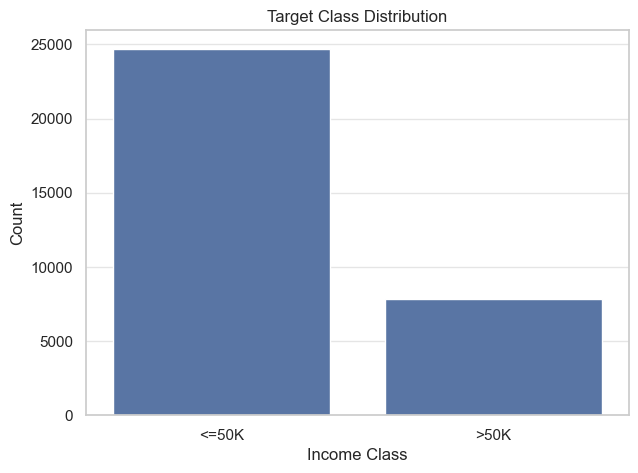

In [ ]:
plt.figure(figsize=(7, 5))

sns.countplot(
    x=y,
    order=y.value_counts().index
)

plt.title("Target Class Distribution")
plt.xlabel("Income Class")
plt.ylabel("Count")
plt.show()

### 3.2 Impact of Class Imbalance

The class distribution shows that the `<=50K` class is more frequent than the `>50K` class. This imbalance can affect model training because a classifier may achieve high accuracy by favoring the majority class.

For this reason, accuracy alone is not sufficient for evaluating model performance. Precision, recall, F1-score, and ROC-AUC will also be used. These metrics provide a more complete view of how well the model identifies the minority class.

### 3.3 Imbalance Handling Strategy

To evaluate the effect of class imbalance, this project will compare standard baseline models with imbalance-aware versions where appropriate.

The main imbalance handling strategy will be class weighting, using `class_weight="balanced"` for models that support it. This approach gives higher importance to the minority class during training without creating synthetic data.

This strategy is selected because it is simple, reproducible, and easy to interpret. More complex methods such as SMOTE can be considered as future work or an optional extension.

## 4. Model Selection and Justification

This project addresses a binary classification problem, where the goal is to predict whether an individual's income is `<=50K` or `>50K`.

To evaluate different modeling approaches, several classification algorithms are compared. The selected models include both white-box models, which are easier to interpret, and black-box models, which may capture more complex nonlinear patterns.

This comparison supports both predictive evaluation and responsible model interpretation.

### 4.1 Model Choice

The following models are selected for comparison:

1. **Logistic Regression**
   A simple linear classification model. It is useful as a baseline and can be interpreted through feature coefficients.

2. **Gaussian Naive Bayes**
   A probabilistic white-box model based on Bayes' theorem. It is fast, simple, and interpretable, although it assumes conditional independence between features.

3. **Decision Tree**
   A rule-based white-box model that can capture nonlinear relationships and feature interactions. Its decision rules can be inspected visually.

4. **Random Forest**
   An ensemble of decision trees. It usually improves predictive performance and reduces overfitting compared with a single decision tree, but is less interpretable.

5. **XGBoost**
   A gradient boosting model designed for strong performance on structured tabular data. It can capture complex nonlinear patterns but is harder to interpret.

6. **Multi-Layer Perceptron (MLP)**
   A neural-network classifier that can learn nonlinear relationships. It requires scaled numerical features and is less interpretable than white-box models.

### 4.2 White-Box and Black-Box Models

The selected models are grouped according to interpretability.

**White-box models**

- Logistic Regression
- Gaussian Naive Bayes
- Decision Tree

These models are easier to inspect and explain. Logistic Regression can be interpreted through feature coefficients, Gaussian Naive Bayes through probabilistic assumptions, and Decision Trees through rule-based splits.

**Black-box models**

- Random Forest
- XGBoost
- Multi-Layer Perceptron

These models may achieve stronger predictive performance by capturing more complex relationships, but their internal decision-making processes are harder to explain. For these models, interpretation will rely on feature importance or model-agnostic analysis.

### 4.3 Hyperparameter Tuning Strategy

The project first trains baseline versions of all selected models using reasonable initial settings. This provides a fair starting point for comparison.

After baseline evaluation, selected models will be tuned using cross-validation. Hyperparameter tuning will focus on parameters that control model complexity and generalization, such as tree depth, number of estimators, learning rate, and neural-network architecture.

This approach allows the project to compare both model families and the effect of improved hyperparameter settings.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer

def to_dense(X):
    return X.toarray() if hasattr(X, "toarray") else X

baseline_models = {
    "Logistic Regression": {
        "model": LogisticRegression(
            max_iter=1000,
            random_state=RANDOM_STATE
        ),
        "preprocessor": preprocessor_scaled
    },
    "Gaussian Naive Bayes": {
        "preprocessor": preprocessor_scaled,
        "model": Pipeline(steps=[
            ("to_dense", FunctionTransformer(to_dense, accept_sparse=True)),
            ("classifier", GaussianNB())
        ])
    },
    "Decision Tree": {
        "model": DecisionTreeClassifier(
            random_state=RANDOM_STATE
        ),
        "preprocessor": preprocessor_unscaled
    },
    "Random Forest": {
        "model": RandomForestClassifier(
            n_estimators=100,
            random_state=RANDOM_STATE,
            n_jobs=-1
        ),
        "preprocessor": preprocessor_unscaled
    },
    "XGBoost": {
        "model": XGBClassifier(
            eval_metric="logloss",
            random_state=RANDOM_STATE,
            n_jobs=-1
        ),
        "preprocessor": preprocessor_unscaled
    },
    "MLP": {
        "model": MLPClassifier(
            hidden_layer_sizes=(64, 32),
            activation="relu",
            solver="adam",
            max_iter=300,
            random_state=RANDOM_STATE,
            early_stopping=True
        ),
        "preprocessor": preprocessor_scaled
    }
}

print(f"Number of baseline models: {len(baseline_models)}")

Number of baseline models: 6


In [ ]:
balanced_models = {
    "Logistic Regression Balanced": {
        "model": LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=RANDOM_STATE
        ),
        "preprocessor": preprocessor_scaled
    },
    "Decision Tree Balanced": {
        "model": DecisionTreeClassifier(
            class_weight="balanced",
            random_state=RANDOM_STATE
        ),
        "preprocessor": preprocessor_unscaled
    },
    "Random Forest Balanced": {
        "model": RandomForestClassifier(
            n_estimators=100,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1
        ),
        "preprocessor": preprocessor_unscaled
    }
}

**Model selection notes**

The selected models provide a broad comparison between simple interpretable classifiers and more complex black-box models. Logistic Regression, Gaussian Naive Bayes, and Decision Tree support interpretability, while Random Forest, XGBoost, and MLP are expected to capture more complex relationships.

Different preprocessing pipelines are used depending on model requirements. Logistic Regression, Gaussian Naive Bayes, and MLP use scaled numerical features, while tree-based models use unscaled numerical features.

Imbalance-aware versions are defined for models that directly support class weighting. MLP is not included in the first imbalance-aware comparison because class weighting is not supported in the same simple way. XGBoost can handle imbalance using `scale_pos_weight`, which may be considered during tuning.

## 5. Model Evaluation and Interpretation

This section trains, evaluates, compares, and interprets the selected classification models. The goal is to assess predictive performance using appropriate classification metrics and to discuss model strengths, weaknesses, and trade-offs.

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    stratify=y_encoded,
    random_state=RANDOM_STATE
)

print(f"Training features: {X_train.shape}")
print(f"Testing features: {X_test.shape}")
print(f"Training target: {y_train.shape}")
print(f"Testing target: {y_test.shape}")

Training features: (26048, 20)
Testing features: (6513, 20)
Training target: (26048,)
Testing target: (6513,)


In [ ]:
split_distribution = pd.DataFrame({
    "train_percentage": y_train.value_counts(normalize=True).mul(100).round(2),
    "test_percentage": y_test.value_counts(normalize=True).mul(100).round(2)
})

split_distribution.index = ["<=50K", ">50K"]

display(split_distribution)

,train_percentage,test_percentage
<=50K,75.92,75.93
>50K,24.08,24.07


**Data splitting notes**

The dataset was split into training and test sets using an 80/20 split. Stratification was applied to preserve the original class distribution in both subsets.

This ensures that the model is trained and evaluated on data with similar target proportions, which is important for imbalanced classification problems.

### 5.2 Evaluation Metrics

Because this is a binary classification problem, model performance is evaluated using the following metrics:

- **Accuracy**: proportion of all predictions that are correct;
- **Precision**: proportion of predicted `>50K` cases that are actually `>50K`;
- **Recall**: proportion of actual `>50K` cases correctly identified;
- **F1-score**: harmonic mean of precision and recall;
- **ROC-AUC**: ability of the model to distinguish between the two income classes across classification thresholds.
- **Matthews Correlation Coefficient (MCC)**: balanced measure that considers true positives, true negatives, false positives, and false negatives.

Since the dataset is imbalanced, accuracy alone is not sufficient. Precision, recall, F1-score, ROC-AUC and MCC provide a more complete evaluation of minority-class performance.

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    matthews_corrcoef,
    confusion_matrix,
    classification_report
)

In [ ]:
def evaluate_classifier(model, X_test, y_test) -> dict:
    """Evaluate a fitted binary classifier on test data."""
    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    else:
        y_score = y_pred

    return {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1_score": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_score),
        "mcc": matthews_corrcoef(y_test, y_pred)
    }

In [ ]:
def plot_confusion_matrix(model, X_test, y_test, title: str) -> None:
    """Plot a confusion matrix for a fitted classifier."""
    y_pred = model.predict(X_test)

    matrix = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5, 4))

    sns.heatmap(
        matrix,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["<=50K", ">50K"],
        yticklabels=["<=50K", ">50K"]
    )

    plt.title(title)
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.show()

In [ ]:
def show_classification_report(model, X_test, y_test) -> None:
    """Display a classification report for a fitted classifier."""
    y_pred = model.predict(X_test)

    print(classification_report(
        y_test,
        y_pred,
        target_names=["<=50K", ">50K"]
    ))

**Evaluation metric notes**

The positive class is defined as `>50K`, encoded as 1. Recall is important because it measures how many actual high-income cases are correctly identified. Precision is also important because it measures how reliable positive predictions are.

F1-score balances precision and recall, while ROC-AUC evaluates how well the model separates the two classes across thresholds. MCC is included because it provides a balanced evaluation that considers all cells of the confusion matrix, making it useful for imbalanced classification problems.

### 5.3 Baseline Model Evaluation

This subsection trains the selected baseline models using the training set and evaluates them on the test set.

Each model is combined with the appropriate preprocessing pipeline to ensure that categorical encoding, numerical imputation, and scaling are applied consistently and without data leakage.

In [ ]:
categorical_preprocessor_dense = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor_dense_scaled = ColumnTransformer(
    transformers=[
        ("num", numeric_preprocessor_scaled, model_numeric_columns),
        ("cat", categorical_preprocessor_dense, model_categorical_columns)
    ]
)

In [ ]:
baseline_results = []
fitted_baseline_models = {}

for model_name, model_config in baseline_models.items():
    pipeline = Pipeline(steps=[
        ("preprocessor", model_config["preprocessor"]),
        ("model", model_config["model"])
    ])

    pipeline.fit(X_train, y_train)

    metrics = evaluate_classifier(pipeline, X_test, y_test)
    metrics["model"] = model_name

    baseline_results.append(metrics)
    fitted_baseline_models[model_name] = pipeline

baseline_results_df = (
    pd.DataFrame(baseline_results)
    .set_index("model")
    .sort_values(by="f1_score", ascending=False)
)

display(baseline_results_df.round(4))

,accuracy,precision,recall,f1_score,roc_auc,mcc
model,,,,,,
XGBoost,0.8715,0.7758,0.6556,0.7107,0.9230,0.6325
MLP,0.8534,0.7169,0.6460,0.6796,0.9077,0.5862
Logistic Regression,0.8543,0.7397,0.6091,0.6681,0.9059,0.5803
Random Forest,0.8408,0.6968,0.5995,0.6445,0.8859,0.5452
Decision Tree,0.8148,0.6221,0.5880,0.6046,0.7554,0.4842
Gaussian Naive Bayes,0.5706,0.3530,0.9407,0.5133,0.7632,0.3512


### 5.4 Imbalance-Aware Model Evaluation

This subsection evaluates models that directly support class weighting. These models are compared with the baseline results to assess whether class weighting improves minority-class recall and F1-score.


In [ ]:
balanced_results = []
fitted_balanced_models = {}

for model_name, model_config in balanced_models.items():
    pipeline = Pipeline(steps=[
        ("preprocessor", model_config["preprocessor"]),
        ("model", model_config["model"])
    ])

    pipeline.fit(X_train, y_train)

    metrics = evaluate_classifier(pipeline, X_test, y_test)
    metrics["model"] = model_name

    balanced_results.append(metrics)
    fitted_balanced_models[model_name] = pipeline

balanced_results_df = (
    pd.DataFrame(balanced_results)
    .set_index("model")
    .sort_values(by="f1_score", ascending=False)
)

display(balanced_results_df.round(4))


,accuracy,precision,recall,f1_score,roc_auc,mcc
model,,,,,,
Logistic Regression Balanced,0.8084,0.5696,0.8355,0.6774,0.9065,0.5683
Random Forest Balanced,0.8372,0.6735,0.6288,0.6504,0.8835,0.5450
Decision Tree Balanced,0.8111,0.5995,0.6492,0.6234,0.7641,0.4983


In [ ]:
baseline_comparison_df = baseline_results_df.copy()
baseline_comparison_df["model_group"] = "Baseline"

balanced_comparison_df = balanced_results_df.copy()
balanced_comparison_df["model_group"] = "Class-weighted"

model_comparison_df = (
    pd.concat([baseline_comparison_df, balanced_comparison_df])
    .sort_values(by="f1_score", ascending=False)
)

display(model_comparison_df.round(4))


,accuracy,precision,recall,f1_score,roc_auc,mcc,model_group
model,,,,,,,
XGBoost,0.8715,0.7758,0.6556,0.7107,0.9230,0.6325,Baseline
MLP,0.8534,0.7169,0.6460,0.6796,0.9077,0.5862,Baseline
Logistic Regression Balanced,0.8084,0.5696,0.8355,0.6774,0.9065,0.5683,Class-weighted
Logistic Regression,0.8543,0.7397,0.6091,0.6681,0.9059,0.5803,Baseline
Random Forest Balanced,0.8372,0.6735,0.6288,0.6504,0.8835,0.5450,Class-weighted
Random Forest,0.8408,0.6968,0.5995,0.6445,0.8859,0.5452,Baseline
Decision Tree Balanced,0.8111,0.5995,0.6492,0.6234,0.7641,0.4983,Class-weighted
Decision Tree,0.8148,0.6221,0.5880,0.6046,0.7554,0.4842,Baseline
Gaussian Naive Bayes,0.5706,0.3530,0.9407,0.5133,0.7632,0.3512,Baseline


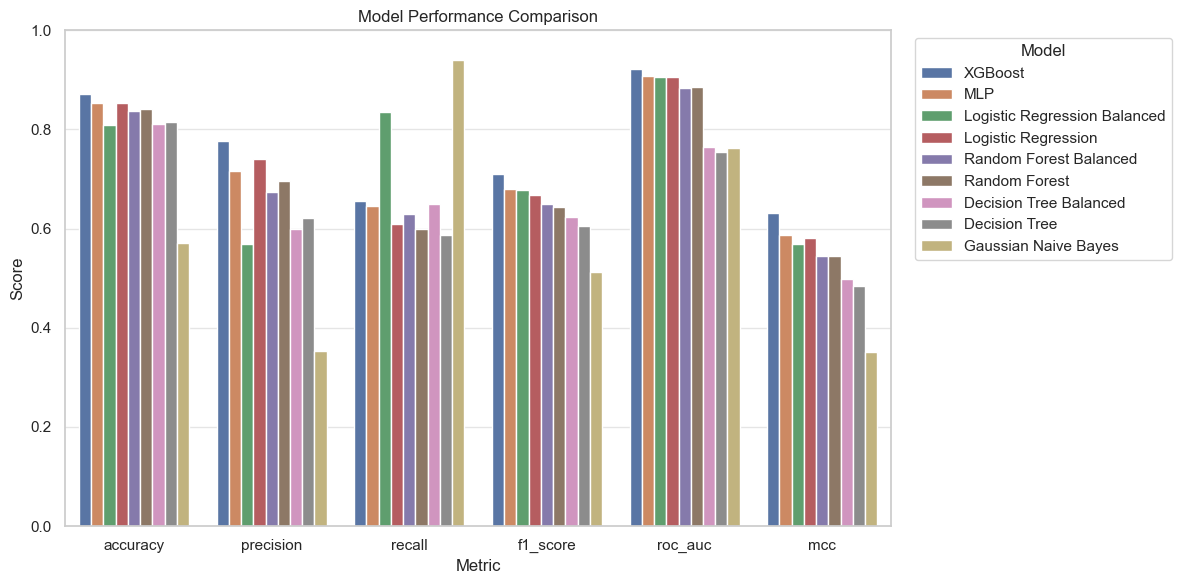

In [ ]:
comparison_metrics = ["accuracy", "precision", "recall", "f1_score", "roc_auc", "mcc"]

comparison_plot_df = (
    model_comparison_df
    .reset_index()
    .melt(
        id_vars=["model", "model_group"],
        value_vars=comparison_metrics,
        var_name="metric",
        value_name="score"
    )
)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=comparison_plot_df,
    x="metric",
    y="score",
    hue="model"
)
plt.title("Model Performance Comparison")
plt.xlabel("Metric")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


### 5.5 Best Model Diagnostics

The best model is selected using F1-score because it balances precision and recall for the positive `>50K` class. The confusion matrix and classification report are then used to inspect the types of errors made by the selected model.


Best model by F1-score: XGBoost


,accuracy,precision,recall,f1_score,roc_auc,mcc,model_group
model,,,,,,,
XGBoost,0.8715,0.7758,0.6556,0.7107,0.923,0.6325,Baseline


              precision    recall  f1-score   support

       <=50K       0.90      0.94      0.92      4945
        >50K       0.78      0.66      0.71      1568

    accuracy                           0.87      6513
   macro avg       0.84      0.80      0.81      6513
weighted avg       0.87      0.87      0.87      6513



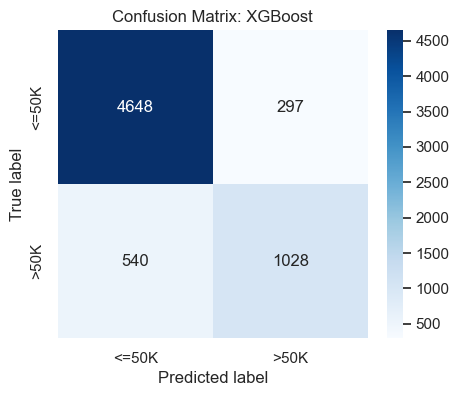

In [ ]:
best_model_name = model_comparison_df["f1_score"].idxmax()

if best_model_name in fitted_baseline_models:
    best_model = fitted_baseline_models[best_model_name]
else:
    best_model = fitted_balanced_models[best_model_name]

print(f"Best model by F1-score: {best_model_name}")
display(model_comparison_df.loc[[best_model_name]].round(4))

show_classification_report(best_model, X_test, y_test)
plot_confusion_matrix(best_model, X_test, y_test, f"Confusion Matrix: {best_model_name}")


**Model comparison notes**

Class weighting is expected to increase recall for the `>50K` class, although it may reduce precision. The final model choice should therefore consider the project objective: if missing high-income cases is more costly, recall and F1-score should be prioritized; if false positive predictions are more costly, precision should receive more weight.


### 5.6 Model Interpretation

This subsection inspects which features contribute most to the selected model. For models with built-in coefficients or feature importance values, transformed feature names are used. For models without built-in importance, permutation importance is computed on the original test features.


In [ ]:
from sklearn.inspection import permutation_importance

def clean_feature_name(feature_name: str) -> str:
    """Remove ColumnTransformer prefixes from feature names."""
    return feature_name.replace("num__", "").replace("cat__", "")

def get_final_estimator(fitted_pipeline):
    """Return the final classifier, including when the model step is itself a Pipeline."""
    estimator = fitted_pipeline.named_steps["model"]

    if isinstance(estimator, Pipeline):
        return estimator.steps[-1][1]

    return estimator

def get_transformed_feature_names(fitted_pipeline) -> list:
    """Return feature names after preprocessing."""
    preprocessor = fitted_pipeline.named_steps["preprocessor"]
    return [
        clean_feature_name(feature_name)
        for feature_name in preprocessor.get_feature_names_out()
    ]

final_estimator = get_final_estimator(best_model)
transformed_feature_names = get_transformed_feature_names(best_model)

if hasattr(final_estimator, "feature_importances_"):
    feature_importance_df = pd.DataFrame({
        "feature": transformed_feature_names,
        "importance": final_estimator.feature_importances_
    }).sort_values(by="importance", ascending=False)
elif hasattr(final_estimator, "coef_"):
    feature_importance_df = pd.DataFrame({
        "feature": transformed_feature_names,
        "importance": np.abs(final_estimator.coef_[0])
    }).sort_values(by="importance", ascending=False)
else:
    permutation_result = permutation_importance(
        best_model,
        X_test,
        y_test,
        scoring="f1",
        n_repeats=5,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    feature_importance_df = pd.DataFrame({
        "feature": X_test.columns,
        "importance": permutation_result.importances_mean
    }).sort_values(by="importance", ascending=False)

top_feature_importance_df = feature_importance_df.head(20)
display(top_feature_importance_df.round(4))


,feature,importance
35,marital.status_Married-civ-spouse,0.5755
1,education.num,0.0368
2,capital.gain,0.0303
57,relationship_Own-child,0.0206
47,occupation_Other-service,0.0191
44,occupation_Farming-fishing,0.0150
8,work.intensity,0.0139
43,occupation_Exec-managerial,0.0137
3,capital.loss,0.0124
59,relationship_Wife,0.0101


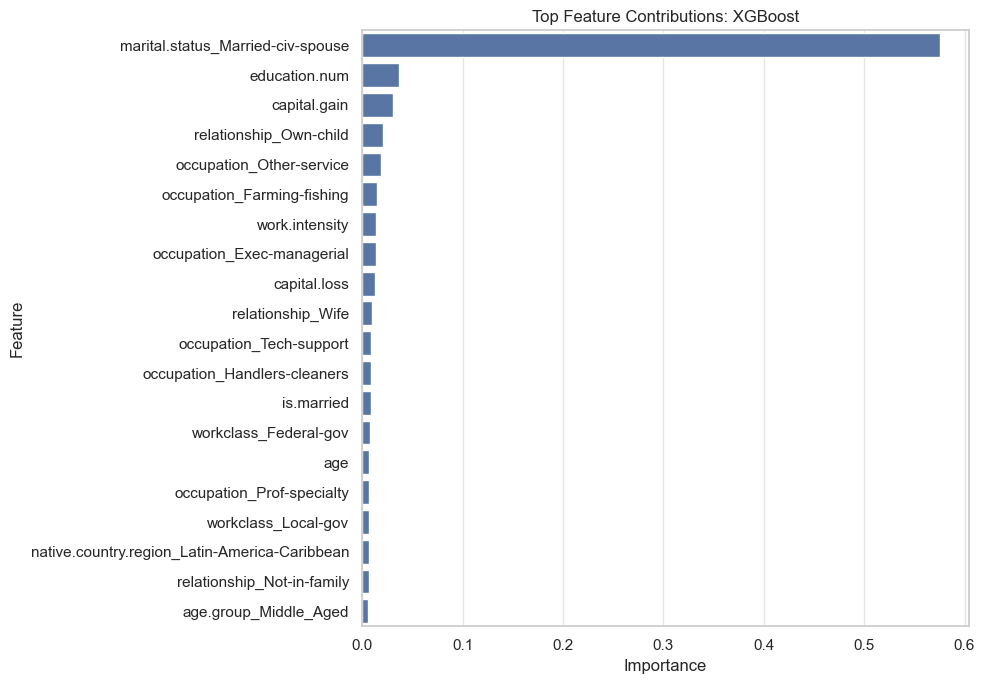

In [ ]:
plt.figure(figsize=(10, 7))
sns.barplot(
    data=top_feature_importance_df,
    x="importance",
    y="feature"
)
plt.title(f"Top Feature Contributions: {best_model_name}")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


### 5.7 Subgroup Performance Analysis

This subsection evaluates whether model performance differs across sensitive or socially meaningful groups. The goal is not to prove fairness, but to identify performance gaps that should be considered before using the model in a real decision-making context.


In [ ]:
def evaluate_by_group(model, X_test: pd.DataFrame, y_test: pd.Series, group_column: str, min_group_size: int = 50) -> pd.DataFrame:
    """Evaluate model performance separately for each group in a column."""
    y_pred = model.predict(X_test)

    group_data = pd.DataFrame({
        "group": X_test[group_column].astype(str).values,
        "y_true": np.asarray(y_test),
        "y_pred": y_pred
    })

    rows = []

    for group_name, group_frame in group_data.groupby("group"):
        if len(group_frame) < min_group_size:
            continue

        rows.append({
            "group": group_name,
            "support": len(group_frame),
            "actual_positive_rate": group_frame["y_true"].mean(),
            "predicted_positive_rate": group_frame["y_pred"].mean(),
            "accuracy": accuracy_score(group_frame["y_true"], group_frame["y_pred"]),
            "precision": precision_score(group_frame["y_true"], group_frame["y_pred"], zero_division=0),
            "recall": recall_score(group_frame["y_true"], group_frame["y_pred"], zero_division=0),
            "f1_score": f1_score(group_frame["y_true"], group_frame["y_pred"], zero_division=0),
            "mcc": matthews_corrcoef(group_frame["y_true"], group_frame["y_pred"])
        })

    return (
        pd.DataFrame(rows)
        .sort_values(by="support", ascending=False)
        .reset_index(drop=True)
    )


In [ ]:
subgroup_columns = ["sex", "race", "native.country.region"]
subgroup_results = {}

for column in subgroup_columns:
    subgroup_results[column] = evaluate_by_group(
        best_model,
        X_test,
        y_test,
        group_column=column,
        min_group_size=50
    )

    print(f"Subgroup performance by {column}")
    display(subgroup_results[column].round(4))


Subgroup performance by sex


,group,support,actual_positive_rate,predicted_positive_rate,accuracy,precision,recall,f1_score,mcc
0,Male,4360,0.3050,0.2622,0.8356,0.7682,0.6602,0.7101,0.5995
1,Female,2153,0.1105,0.0845,0.9443,0.8242,0.6303,0.7143,0.6916


Subgroup performance by race


,group,support,actual_positive_rate,predicted_positive_rate,accuracy,precision,recall,f1_score,mcc
0,White,5627,0.2550,0.2165,0.8665,0.7808,0.6627,0.7169,0.6340
1,Black,579,0.1278,0.1036,0.9171,0.7167,0.5811,0.6418,0.5997
2,Asian-Pac-Islander,196,0.2602,0.2041,0.8418,0.7500,0.5882,0.6593,0.5653
3,Amer-Indian-Eskimo,67,0.1045,0.0746,0.9104,0.6000,0.4286,0.5000,0.4600


Subgroup performance by native.country.region


,group,support,actual_positive_rate,predicted_positive_rate,accuracy,precision,recall,f1_score,mcc
0,North-America,5856,0.2456,0.2080,0.8671,0.7709,0.6530,0.7071,0.6255
1,Latin-America-Caribbean,286,0.0874,0.0559,0.9545,0.8750,0.5600,0.6829,0.6788
2,Other,136,0.2353,0.1985,0.9191,0.8889,0.7500,0.8136,0.7669
3,Asia,132,0.2955,0.2727,0.8409,0.7500,0.6923,0.7200,0.6101
4,Europe,103,0.3301,0.2718,0.8641,0.8571,0.7059,0.7742,0.6848


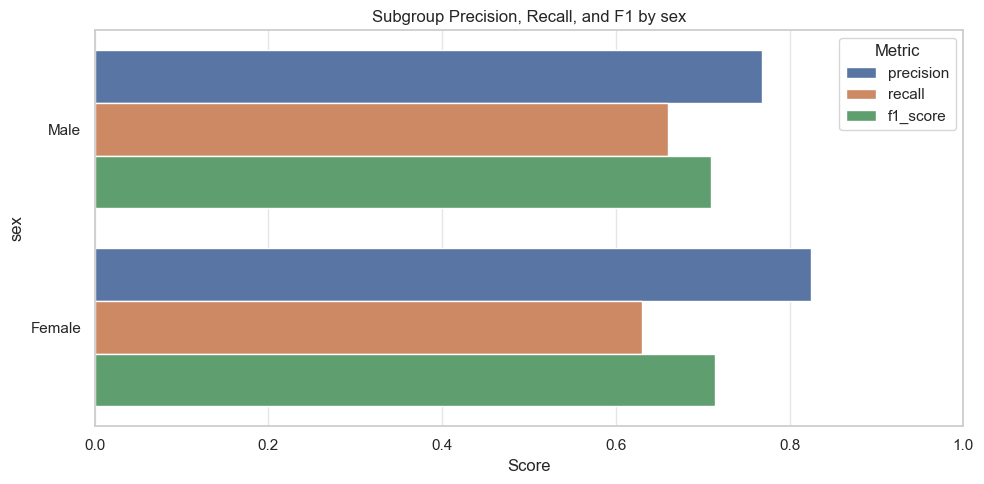

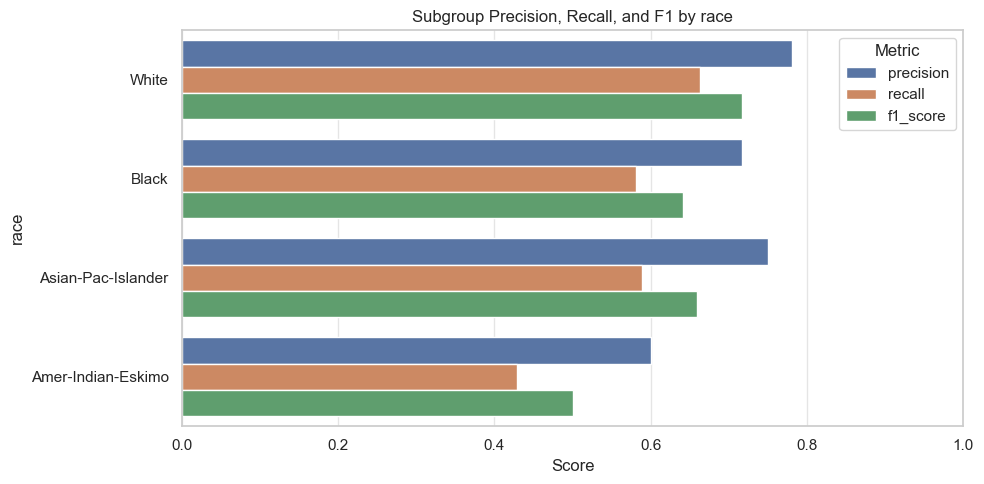

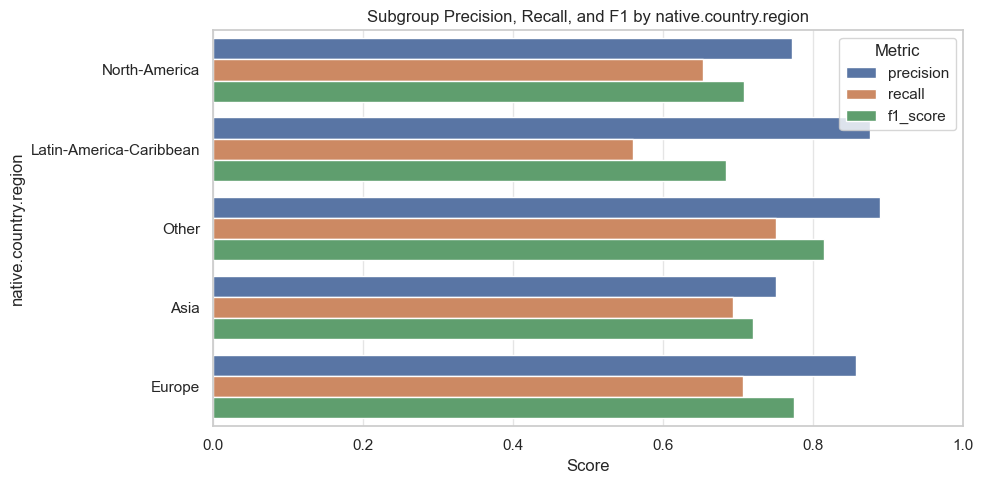

In [ ]:
for column, result_df in subgroup_results.items():
    if result_df.empty:
        continue

    plot_df = result_df.melt(
        id_vars=["group", "support"],
        value_vars=["precision", "recall", "f1_score"],
        var_name="metric",
        value_name="score"
    )

    plt.figure(figsize=(10, 5))
    sns.barplot(
        data=plot_df,
        x="score",
        y="group",
        hue="metric"
    )
    plt.title(f"Subgroup Precision, Recall, and F1 by {column}")
    plt.xlabel("Score")
    plt.ylabel(column)
    plt.xlim(0, 1)
    plt.legend(title="Metric")
    plt.tight_layout()
    plt.show()


**Interpretation and subgroup analysis notes**

Feature importance should be interpreted carefully because one-hot encoded categories can split the influence of a single original variable across many transformed columns. Subgroup metrics should also be treated as diagnostic evidence rather than a complete fairness audit. Smaller groups may have unstable scores, and differences in observed performance can reflect both model behavior and historical patterns in the dataset.


## 6. Reproducibility, Limitations, and Conclusion

### 6.1 Reproducibility

The project uses a fixed `RANDOM_STATE` for data splitting and model initialization where supported. Preprocessing is handled inside sklearn pipelines, which reduces data leakage by fitting imputers, scalers, and encoders only on the training data during model training.

### 6.2 Limitations

The Adult Census Income dataset is historical and may not represent current income patterns. It also contains sensitive demographic variables and may reflect social and economic bias. Predictive performance should therefore not be interpreted as evidence that income outcomes are fair or causally determined by the included features.

The subgroup analysis is limited to observed test-set performance and does not cover all fairness definitions. A stronger deployment-oriented analysis would require threshold tuning, calibration checks, external validation data, and stakeholder-specific fairness criteria.

### 6.3 Conclusion

This project built and compared multiple classification models for predicting whether income exceeds `50K`. The final model should be selected based on both predictive performance and responsible-use considerations. Accuracy alone is insufficient for this dataset because of class imbalance, so F1-score, recall, ROC-AUC, MCC, confusion matrices, and subgroup performance provide a more complete basis for evaluation.
